In [66]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import cKDTree
from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import to_rgba
from matplotlib.lines import Line2D

# ---- Global variables ----
GENES = ['CDH5', 'MMP1', 'COL1A1', 'KDR', 'VWF', 'PECAM1', 'VEGFA', 'DLL4', 'ITGA6', 'SEMA3F', 'JAG1', 'FLT1', 'PDGFB', 'COL1A2', 'APLN', 'PDGFRB', 'ANGPT2', 'ICAM1']
IMAGE_KEY = "source_folder"          # one physical image per source_folder
output_dir = Path(".")

# Cell-type ordering / colours (capitalised labels, matching part1/part3).
CT_ORDER = ["Endothelial", "Fibroblast", "Unknown", "Zero Reads"]
CT_COLORS = {"Endothelial": "#d62728", "Fibroblast": "#1f77b4", "Unknown": "#7f7f7f", "Zero Reads": "#cccccc"}

# Neighbourhood-analysis parameters.
K_SPATIAL = 15                       # neighbours used for composition / expression
RADIUS_UM = 30.0                     # radius (um) for the local-density count
NICHE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1", "COL1A1", "COL1A2"}
N_NICHES = 4
# Gene-module parameters.
MODULE_LINEAGE = "Endothelial"       # dominant population
MIN_ON = 20                          # each gene ON in >= this many cells (stable odds ratio)
MODULE_MARKER_EXCLUDE = {"CDH5", "VWF", "PECAM1"}
TIME_ORDER = ["6h", "day1", "day2", "day4"]

# ---- Data: enriched per-cell table from part 3 (genes + cell_type + gene-state clusters) ----
all_data = pd.read_csv(output_dir / "clustered_data_with_states.csv")
X = all_data[list(GENES)].astype(int).to_numpy()

# Cluster co-location z-score matrix from part 3.
z_all = pd.read_csv(output_dir / "cluster_colocation_zscores.csv", index_col=0)

# Rebuild the gene-state cluster metadata from the saved per-cell "group" label
# (group = cluster name for clustered cells, else "unknown" / "no reads").
clustered_cells = all_data[all_data["bmm"] >= 0]
cluster_ids = np.sort(clustered_cells["bmm"].unique())
cluster_name_of = clustered_cells.groupby("bmm")["group"].first().to_dict()
cluster_names = [cluster_name_of[c] for c in cluster_ids]
all_order = cluster_names + ["unknown", "no reads"]

# Gene-state cluster colours (grey for unknown / no-reads).
cluster_cmap = plt.get_cmap("tab10", len(cluster_names))
cluster_palette = {name: to_rgba(cluster_cmap(i)) for i, name in enumerate(cluster_names)}
cluster_palette["unknown"] = to_rgba("0.55")
cluster_palette["no reads"] = to_rgba("0.82")


In [67]:
# ---- Functions ----
def timepoint_of(name):
    """Map an image / source_folder name to a timepoint bin (6h / day1 / day2 / day4)."""
    s = str(name).lower().replace(" ", "")
    if "6h" in s:                                  return "6h"
    if "day4" in s or re.search(r"d4(?!\d)", s):   return "day4"
    if "day2" in s or re.search(r"d2(?!\d)", s):   return "day2"
    if "day1" in s or re.search(r"d1(?!\d)", s):   return "day1"
    return "unknown"


## 3. Neighbourhood analysis

We now describe each cell by its **local micro-environment** rather than its own genes:
the cell-type composition of its spatial neighbours, how many neighbours express each
gene, the **Shannon entropy** of the neighbourhood (diversity), and the **local
density**. Clustering these neighbourhood vectors defines recurring tissue **niches**

In [68]:
# NEIGHBOURHOOD ANALYSIS. For every cell we describe its local micro-environment from
# its k nearest spatial neighbours *within the same image* (in microns):
#   - cell-type composition   (% endo/fibro/no reads/unknown  CT_ORDER)
#   - neighbourhood expression (% of neighbours expressing each gene)
#   - Shannon entropy          (diversity of neighbour cell types)
#   - local density            (number of neighbours within RADIUS_UM)
celltype_onehot = (pd.get_dummies(all_data["cell_type"])
                   .reindex(columns=CT_ORDER, fill_value=0).to_numpy().astype(float))

neighbour_celltype_fraction = np.zeros((len(all_data), len(CT_ORDER)))
neighbour_gene_fraction = np.zeros((len(all_data), len(GENES)))
neighbour_entropy = np.zeros(len(all_data))
local_density = np.zeros(len(all_data))

for image_name, sub in all_data.groupby(IMAGE_KEY):
    cell_positions = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    tree = cKDTree(coords)
    n_query = min(K_SPATIAL + 1, len(sub))
    distances, neighbour_idx = tree.query(coords, k=n_query)
    neighbour_idx = np.atleast_2d(neighbour_idx)
    neighbours = neighbour_idx[:, 1:] if neighbour_idx.shape[1] > 1 else neighbour_idx   # drop self column
    global_neighbours = cell_positions[neighbours]                                        # local -> global indices
    neighbour_celltype_fraction[cell_positions] = celltype_onehot[global_neighbours].mean(axis=1)
    neighbour_gene_fraction[cell_positions] = X[global_neighbours].mean(axis=1)
    composition = neighbour_celltype_fraction[cell_positions]
    neighbour_entropy[cell_positions] = -np.sum(
        np.where(composition > 0, composition * np.log(composition), 0.0), axis=1)
    local_density[cell_positions] = np.array(
        [len(ball) - 1 for ball in tree.query_ball_point(coords, RADIUS_UM)])

neighbourhood = pd.DataFrame(neighbour_celltype_fraction,
                             columns=[f"nb_%{ct}" for ct in CT_ORDER], index=all_data.index)
neighbourhood = pd.concat(
    [neighbourhood,
     pd.DataFrame(neighbour_gene_fraction, columns=[f"nb_{gene}" for gene in GENES], index=all_data.index)],
    axis=1)
neighbourhood["nb_entropy"] = neighbour_entropy
neighbourhood["nb_density"] = local_density
all_data[neighbourhood.columns] = neighbourhood


C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_42496\3373573389.py:28: RuntimeWarning: divide by zero encountered in log
  np.where(composition > 0, composition * np.log(composition), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_42496\3373573389.py:28: RuntimeWarning: invalid value encountered in multiply
  np.where(composition > 0, composition * np.log(composition), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_42496\3373573389.py:28: RuntimeWarning: divide by zero encountered in log
  np.where(composition > 0, composition * np.log(composition), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_42496\3373573389.py:28: RuntimeWarning: invalid value encountered in multiply
  np.where(composition > 0, composition * np.log(composition), 0.0), axis=1)
C:\Users\taylorhearn\AppData\Local\Temp\ipykernel_42496\3373573389.py:28: RuntimeWarning: divide by zero encountered in log
  np.where(composition > 0, composition * np.log(composition), 0

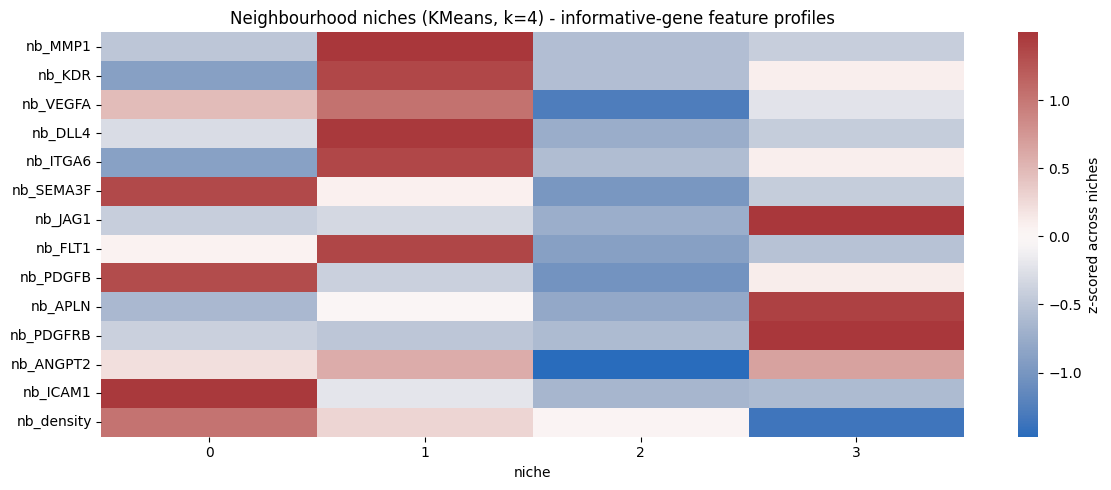

In [69]:
# Cluster the NEIGHBOURHOODS into recurring micro-environments ("niches"). The population
# is overwhelmingly endothelial, so cell-type composition, its Shannon entropy and the
# lineage-defining markers dominate any clustering that includes them - niches then collapse
# onto an uninteresting endothelial-density axis. We therefore build niches from the
# NEIGHBOURHOOD EXPRESSION of the informative (non-marker) genes only.
niche_genes = [g for g in GENES if g not in NICHE_MARKER_EXCLUDE]
nb_feature_cols = [f"nb_{g}" for g in niche_genes] + ["nb_density"]
Zf = StandardScaler().fit_transform(all_data[nb_feature_cols].values)

all_data["niche"] = KMeans(n_clusters=N_NICHES, n_init=10, random_state=0).fit_predict(Zf)

# Mean feature profile of each niche (z-scored across niches so genes and density are comparable).
niche_profile = all_data.groupby("niche")[nb_feature_cols].mean()
niche_profile_z = (niche_profile - niche_profile.mean()) / (niche_profile.std() + 1e-9)
plt.figure(figsize=(12, 5))
sns.heatmap(niche_profile_z.T, cmap="vlag", center=0,
            cbar_kws={"label": "z-scored across niches"})
plt.title(f"Neighbourhood niches (KMeans, k={N_NICHES}) - informative-gene feature profiles")
plt.xlabel("niche"); plt.tight_layout(); plt.show()


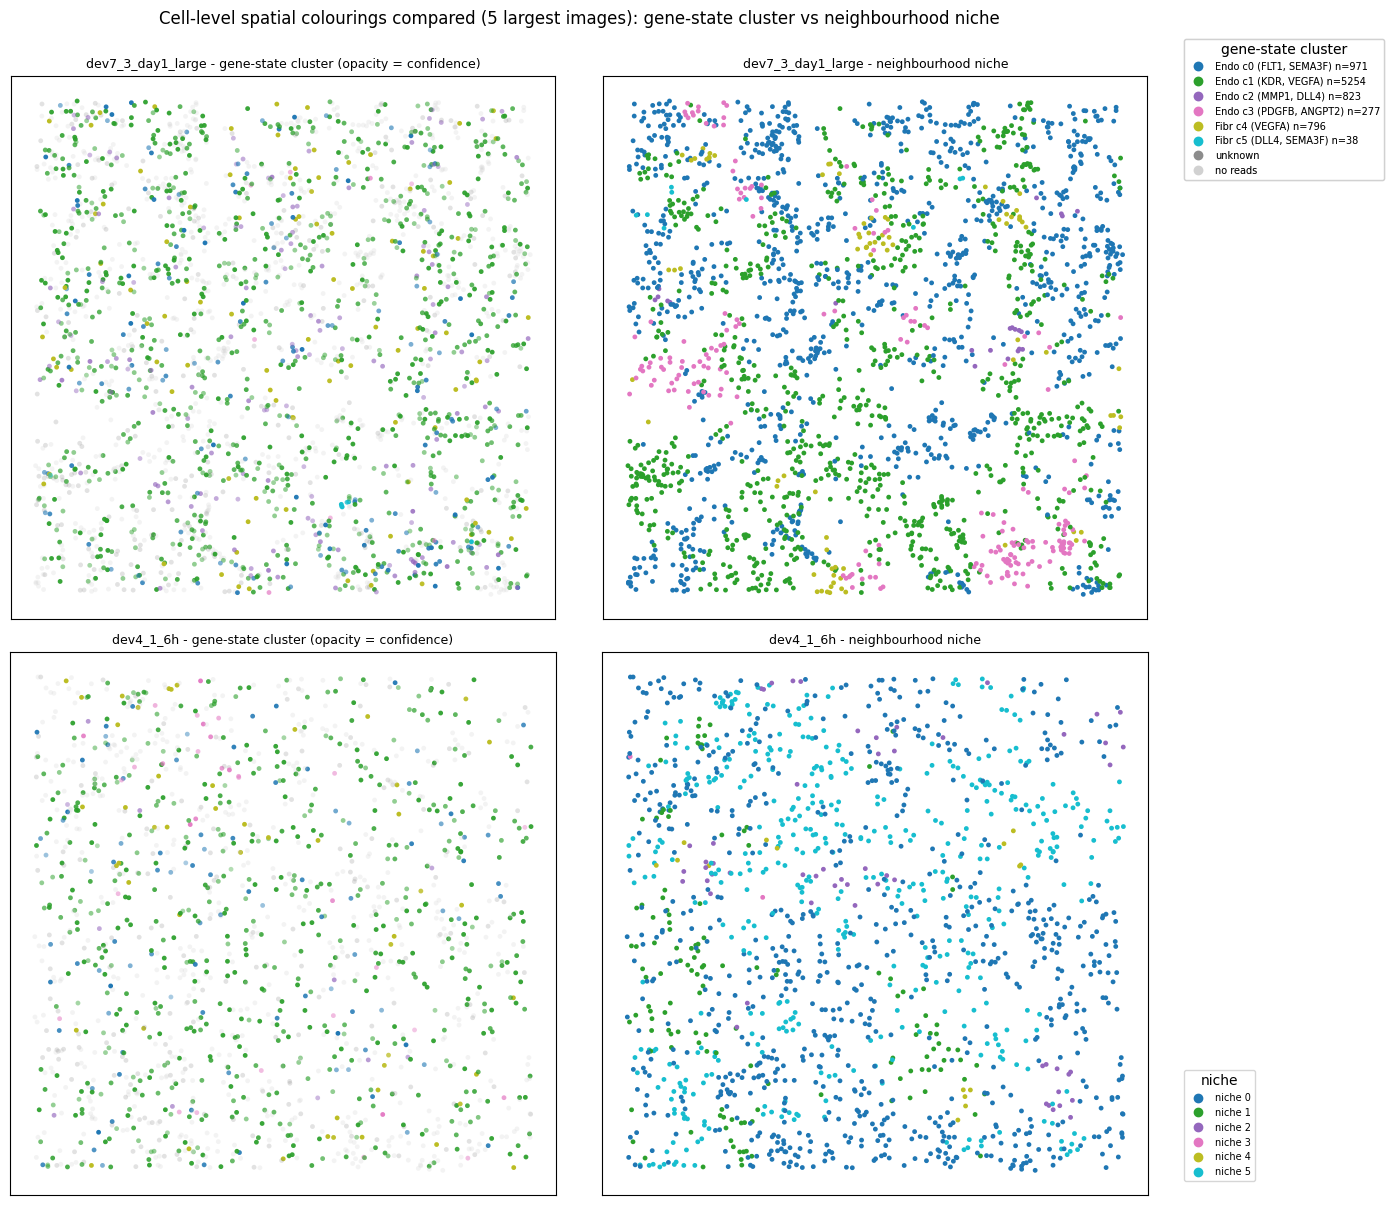

In [39]:
# Compare two per-cell spatial colourings on the largest images: gene-state cluster vs niche.
niche_ids = np.sort(all_data["niche"].unique())
niche_cmap = plt.get_cmap("tab10", len(niche_ids))
niche_color = {nid: niche_cmap(i) for i, nid in enumerate(niche_ids)}

top_images = all_data[IMAGE_KEY].value_counts().head(2).index.tolist()
fig, axes = plt.subplots(len(top_images), 2, figsize=(12, 6 * len(top_images)), squeeze=False)
for row, image_name in enumerate(top_images):
    sub = all_data[all_data[IMAGE_KEY] == image_name]

    rgba = np.array([cluster_palette[g] for g in sub["group"]])
    conf = sub["bmm_confidence"].to_numpy(dtype=float)
    rgba[:, 3] = np.where(np.isnan(conf), 0.25, np.clip(conf, 0.05, 1.0))  # opacity = confidence
    axes[row, 0].scatter(sub["x_um"], sub["y_um"], s=12, c=rgba, edgecolors="none")
    axes[row, 0].set_title(f"{image_name} - gene-state cluster (opacity = confidence)", fontsize=9)

    axes[row, 1].scatter(sub["x_um"], sub["y_um"], s=12, edgecolors="none",
                         c=[niche_color[n] for n in sub["niche"]])
    axes[row, 1].set_title(f"{image_name} - neighbourhood niche", fontsize=9)

    for col in (0, 1):
        axes[row, col].set_aspect("equal"); axes[row, col].set_xticks([]); axes[row, col].set_yticks([])

cluster_handles = [Line2D([0], [0], marker="o", linestyle="", color=cluster_palette[name], label=name)
                   for name in all_order]
niche_handles = [Line2D([0], [0], marker="o", linestyle="", color=niche_color[nid], label=f"niche {nid}")
                 for nid in niche_ids]
leg1 = fig.legend(handles=cluster_handles, title="gene-state cluster", fontsize=7,
                  loc="upper left", bbox_to_anchor=(1.0, 0.98))
fig.add_artist(leg1)
fig.legend(handles=niche_handles, title="niche", fontsize=7,
           loc="lower left", bbox_to_anchor=(1.0, 0.02))
fig.suptitle("Cell-level spatial colourings compared (5 largest images): "
             "gene-state cluster vs neighbourhood niche", y=1.0)
plt.tight_layout(); plt.show()


### Conclusions - neighbourhood niches

**Approach.** Each cell is described by its k-nearest neighbours (same image): neighbourhood
gene expression and local density. Niches = KMeans on those features. We deliberately use
only the **informative (non-marker) genes** and drop cell-type composition + Shannon entropy,
because in a majority-endothelial sample those just encode "endothelial-dense vs mixed" and
swamp the functional signal.

**Assumptions / drawbacks.** The neighbour count k, the radius and the number of niches are
chosen, not learned; KMeans forces round, roughly equal clusters. Niches are partly circular
with the gene-state clusters (both use spatial neighbours).

**Biology.** The niches are **functional micro-environments** - e.g. an `MMP1`/`VEGFA`
proteolytic-angiogenic niche, a `FLT1`/`DLL4`/`ITGA6` tip/sprouting niche, an `APLN`/`ANGPT2`
niche and a `PDGFRB`/`JAG1` mural-associated niche - rather than a trivial endothelial-density
gradient.

**Do the methods agree?** Yes - the niche fingerprints line up with the gene-state clusters
(`P(niche | state)`) and with the gene modules (module-activity-per-niche in Section 4), and
the cluster co-location permutation test independently shows the angiogenic states sitting together.
Three views of the tissue converge on the same programmes.

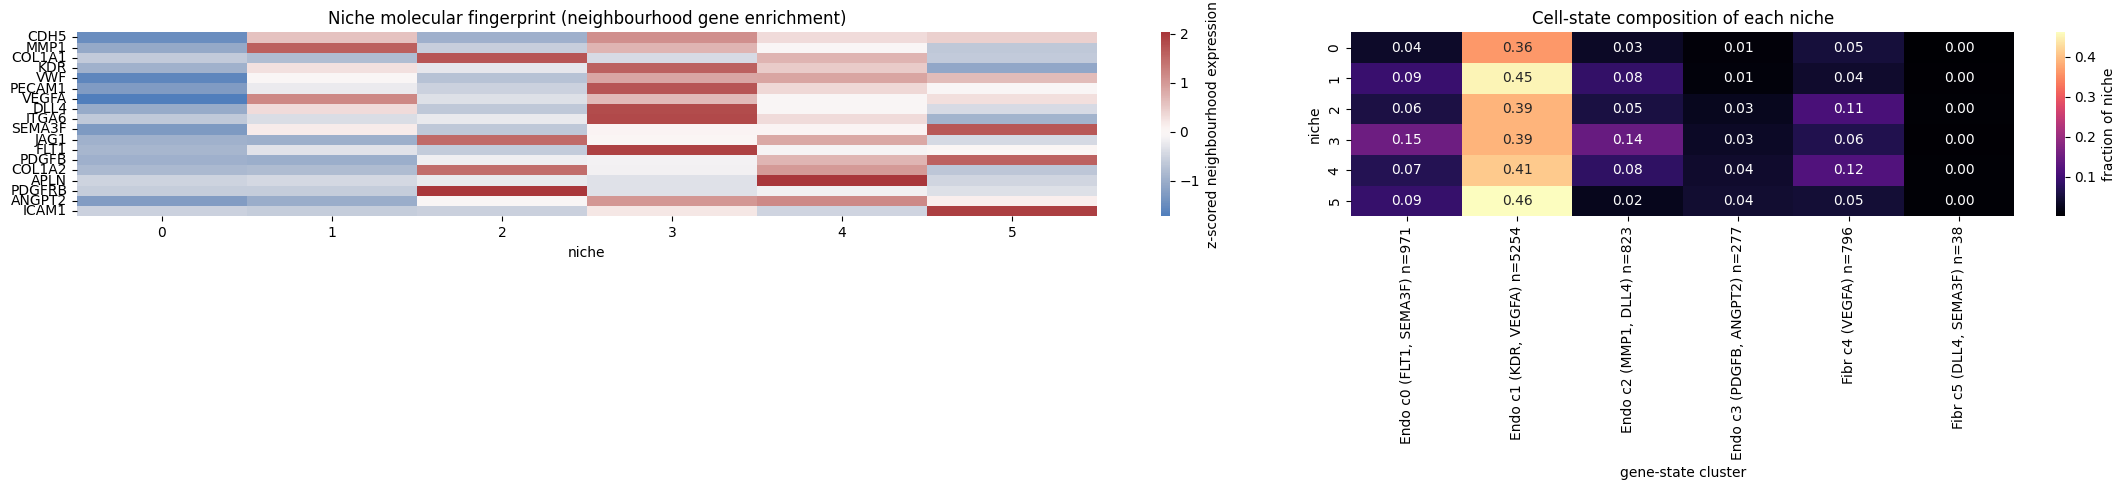

Niche fingerprints (top enriched neighbourhood genes):
  niche 0 (n=4,589): APLN, ICAM1, PDGFRB, COL1A1
  niche 1 (n=2,476): MMP1, VEGFA, CDH5, DLL4
  niche 2 (n=1,311): PDGFRB, COL1A1, JAG1, COL1A2
  niche 3 (n=1,839): FLT1, ITGA6, DLL4, PECAM1
  niche 4 (n=1,061): APLN, ANGPT2, COL1A2, VWF
  niche 5 (n=1,771): ICAM1, SEMA3F, PDGFB, VWF


In [40]:
# WHAT DEFINES EACH NICHE?
#  (left)  z-scored mean neighbourhood gene expression -> the molecular signature of each
#          niche (which genes are enriched among a cell's neighbours in that niche).
#  (right) gene-state cluster composition -> which cell states build each niche.
nb_gene_cols = [f"nb_{g}" for g in GENES]
niche_gene = all_data.groupby("niche")[nb_gene_cols].mean()
niche_gene_z = (niche_gene - niche_gene.mean()) / (niche_gene.std() + 1e-9)
niche_gene_z.columns = GENES

state_comp = pd.crosstab(all_data["niche"], all_data["bmm"], normalize="index").drop(columns=[-1], errors="ignore")
state_comp.columns = [cluster_name_of.get(c, str(c)) for c in state_comp.columns]

fig, axes = plt.subplots(1, 2, figsize=(22, 5), gridspec_kw={"width_ratios": [2, 1.3]})
sns.heatmap(niche_gene_z.T, cmap="vlag", center=0, ax=axes[0],
            cbar_kws={"label": "z-scored neighbourhood expression"})
axes[0].set_title("Niche molecular fingerprint (neighbourhood gene enrichment)")
axes[0].set_xlabel("niche")
sns.heatmap(state_comp, cmap="magma", annot=True, fmt=".2f", ax=axes[1],
            cbar_kws={"label": "fraction of niche"})
axes[1].set_title("Cell-state composition of each niche")
axes[1].set_xlabel("gene-state cluster"); axes[1].set_ylabel("niche")
plt.tight_layout(); plt.show()

print("Niche fingerprints (top enriched neighbourhood genes):")
for niche_id in niche_gene_z.index:
    top = niche_gene_z.loc[niche_id].sort_values(ascending=False).head(4).index.tolist()
    print(f"  niche {niche_id} (n={int((all_data['niche'] == niche_id).sum()):,}): {', '.join(top)}")


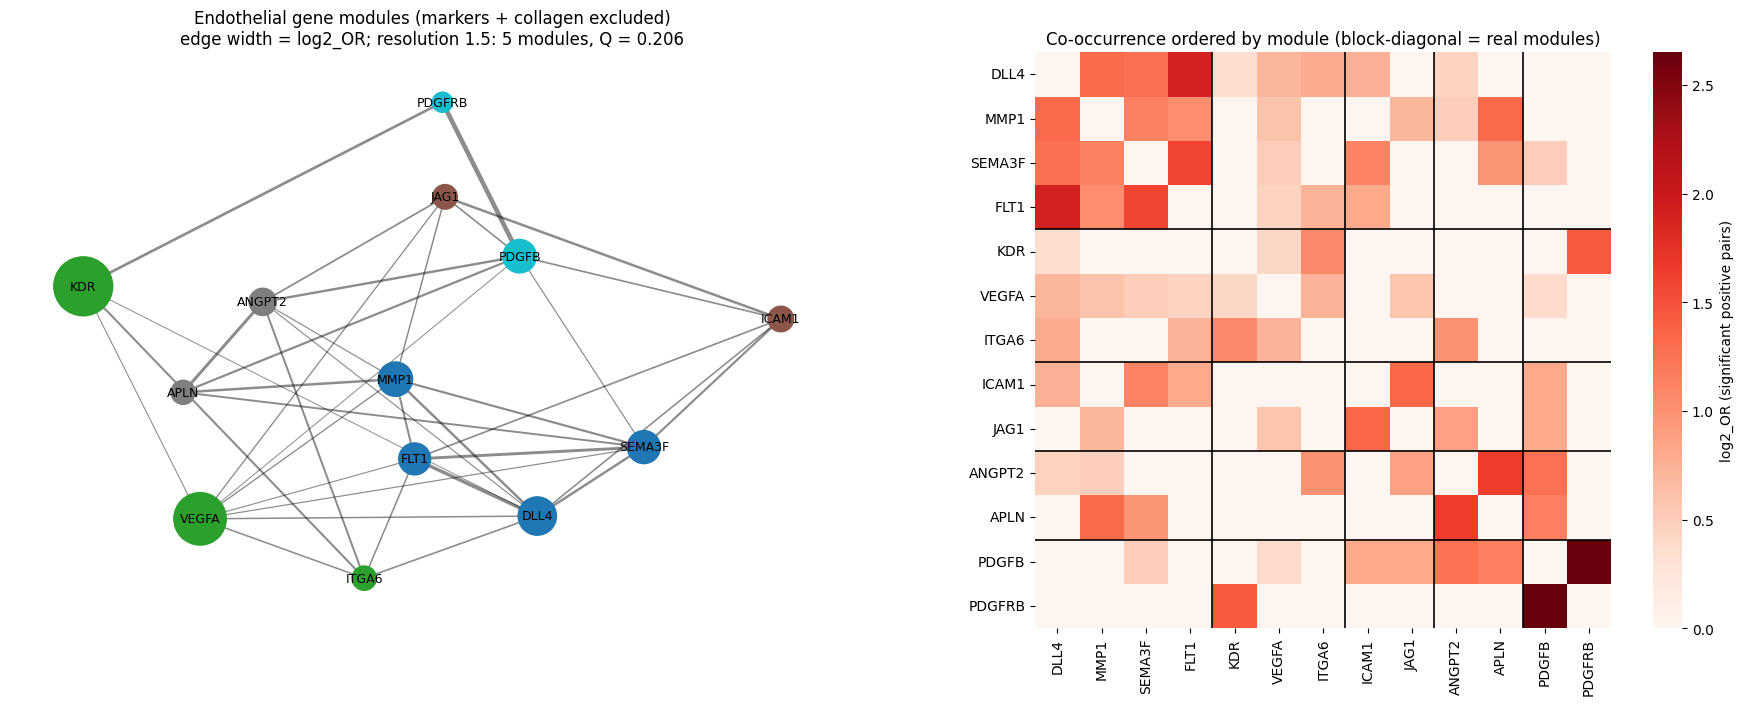

Endothelial gene modules (log2_OR, resolution 1.5): 5 modules, Q = 0.206
  module 0: DLL4, MMP1, SEMA3F, FLT1
  module 1: KDR, VEGFA, ITGA6
  module 2: ICAM1, JAG1
  module 3: ANGPT2, APLN
  module 4: PDGFB, PDGFRB


In [46]:
# ===== SECTION 4: ENDOTHELIAL GENE MODULES (5-module split) =====
# Co-occurrence graph on endothelial cells: exclude pan-endothelial markers + collagen, take the
# resolution-1.5 greedy-modularity partition. Weighting edges by the log2 odds ratio (rather than
# phi) splits the perivascular block into a mural (PDGFB/PDGFRB) and a remodelling (ANGPT2/APLN)
# module -> 5 modules; phi keeps those two merged (4 modules). The split is favoured spatially
# (PDGFRB -> mural niche, APLN/ANGPT2 -> remodelling niche), so we report it here.
MODULE_RESOLUTION = 1.5
MODULE_WEIGHT = "log2_OR"                    # phi -> 4 modules; log2 OR -> 5 (splits perivascular)
MODULE_GENES = [g for g in GENES if g not in MODULE_MARKER_EXCLUDE | {"COL1A1", "COL1A2"}]

Bm = all_data[(all_data["cell_type"] == MODULE_LINEAGE) & all_data["has_reads"]][MODULE_GENES].to_numpy()
on_count, on_freq = Bm.sum(0), Bm.mean(0)

rows = []
for i in range(len(MODULE_GENES)):
    for j in range(i + 1, len(MODULE_GENES)):
        a = int(((Bm[:, i] == 1) & (Bm[:, j] == 1)).sum())
        b, c = int(on_count[i]) - a, int(on_count[j]) - a
        d = len(Bm) - a - b - c
        fisher_stat, p = fisher_exact([[a, b], [c, d]])
        odds = ((a + 0.5) * (d + 0.5)) / ((b + 0.5) * (c + 0.5))
        denom = np.sqrt((a + b) * (c + d) * (a + c) * (b + d))
        phi = (a * d - b * c) / denom if denom else 0.0        # Matthews correlation of the two 0/1 vectors
        rows.append((MODULE_GENES[i], MODULE_GENES[j], np.log2(odds), phi, p, int(on_count[i]), int(on_count[j])))
gp = pd.DataFrame(rows, columns=["g1", "g2", "log2_OR", "phi", "pvalue", "n1", "n2"])
gp["FDR"] = multipletests(gp.pvalue, method="fdr_bh")[1]
pos = gp[(gp.log2_OR > 0) & (gp.FDR < 0.05) & (gp.n1 >= MIN_ON) & (gp.n2 >= MIN_ON)].copy()

Gg = nx.Graph(); Gg.add_nodes_from(MODULE_GENES)
for r in pos.itertuples():
    Gg.add_edge(r.g1, r.g2, weight=float(getattr(r, MODULE_WEIGHT)))
communities = list(nx.community.greedy_modularity_communities(Gg, weight="weight", resolution=MODULE_RESOLUTION))
Q = nx.community.modularity(Gg, communities, weight="weight")
module_of = {g: m for m, com in enumerate(communities) for g in com}
n_mod = len(communities)

# --- graph (edge width = weight) + module-ordered co-occurrence heatmap ---
mcmap = plt.get_cmap("tab10", max(n_mod, 1))
conn = [g for g in Gg.nodes() if Gg.degree(g) > 0]
Hs = Gg.subgraph(conn)
lay = nx.spring_layout(Hs, weight="weight", k=1.4, seed=1)
nsz = [200 + 1600 * on_freq[MODULE_GENES.index(g)] / on_freq.max() for g in Hs.nodes()]
ncol = [mcmap(module_of[g]) for g in Hs.nodes()]
ew = np.array([Hs[u][v]["weight"] for u, v in Hs.edges()]); ew = 0.3 + 3.0 * ew / ew.max()

fig, axg = plt.subplots(1, 2, figsize=(18, 7))
nx.draw_networkx_edges(Hs, lay, ax=axg[0], width=ew, alpha=0.45)
nx.draw_networkx_nodes(Hs, lay, ax=axg[0], node_size=nsz, node_color=ncol)
nx.draw_networkx_labels(Hs, lay, ax=axg[0], font_size=9)
axg[0].set_title(f"{MODULE_LINEAGE} gene modules (markers + collagen excluded)\n"
                 f"edge width = {MODULE_WEIGHT}; resolution {MODULE_RESOLUTION}: {n_mod} modules, Q = {Q:.3f}")
axg[0].axis("off")

order = [g for com in communities for g in sorted(com, key=lambda x: -on_freq[MODULE_GENES.index(x)])]
Mh = pd.DataFrame(0.0, index=order, columns=order)
for r in pos.itertuples():
    w = float(getattr(r, MODULE_WEIGHT))
    Mh.loc[r.g1, r.g2] = w; Mh.loc[r.g2, r.g1] = w
sns.heatmap(Mh, cmap="Reds", square=True, ax=axg[1], cbar_kws={"label": f"{MODULE_WEIGHT} (significant positive pairs)"})
for bnd in np.cumsum([len(c) for c in communities])[:-1]:
    axg[1].axhline(bnd, color="k", lw=1.2); axg[1].axvline(bnd, color="k", lw=1.2)
axg[1].set_title("Co-occurrence ordered by module (block-diagonal = real modules)")
plt.tight_layout(); plt.show()

print(f"{MODULE_LINEAGE} gene modules ({MODULE_WEIGHT}, resolution {MODULE_RESOLUTION}): {n_mod} modules, Q = {Q:.3f}")
for m, com in enumerate(communities):
    print(f"  module {m}: {', '.join(sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)]))}")
isolated = [g for g in MODULE_GENES if Gg.degree(g) == 0]
if isolated:
    print(f"  no significant positive partner: {', '.join(isolated)}")


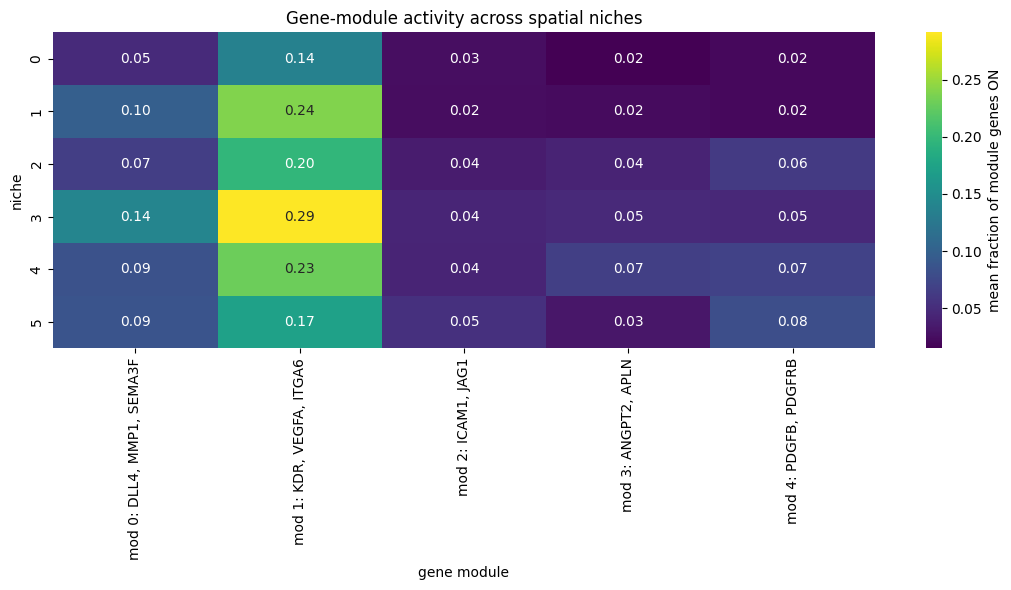

In [42]:
# GENE-MODULE ACTIVITY PER NICHE. For every cell, the fraction of each module's genes
# that are ON; averaged per niche -> which co-firing gene programmes are active where.
module_labels = {m: f"mod {m}: {', '.join(sorted(com, key=lambda g: -on_freq[MODULE_GENES.index(g)])[:3])}"
                 for m, com in enumerate(communities)}
module_activity = pd.DataFrame(
    {module_labels[m]: all_data[list(com)].mean(axis=1) for m, com in enumerate(communities)})
module_activity["niche"] = all_data["niche"].to_numpy()
niche_module = module_activity.groupby("niche").mean()

plt.figure(figsize=(1.4 * len(communities) + 4, 0.5 * all_data["niche"].nunique() + 3))
sns.heatmap(niche_module, cmap="viridis", annot=True, fmt=".2f",
            cbar_kws={"label": "mean fraction of module genes ON"})
plt.title("Gene-module activity across spatial niches")
plt.xlabel("gene module"); plt.ylabel("niche")
plt.tight_layout(); plt.show()


In [43]:
# ==========================================================================
# IS STATE c1 (APLN/PDGFB sprout) SPATIALLY CLOSE TO PERICYTES?
# Pericyte/mural marker in this panel = PDGFRB. c1 expresses PDGFB, the ligand tip cells
# use to RECRUIT pericytes, so it should sit nearer PDGFRB+ cells than other endothelial
# states. Three independent tests, all restricted to within-image neighbours.
# ==========================================================================
endo = all_data[(all_data.cell_type == "Endothelial") & all_data.has_reads & (all_data.bmm >= 0)].copy()
endo_ids = sorted(endo.bmm.unique())
state_name = {state_id: cluster_name_of.get(state_id, str(state_id)) for state_id in endo_ids}
c1 = max(endo_ids, key=lambda state_id: all_data.loc[all_data.bmm == state_id, "APLN"].mean())   # the APLN/PDGFB state
print(f"c1 (APLN/PDGFB sprout) = {state_name[c1]}\n")

# (1) Fraction of each cell's 15 nearest neighbours that are PDGFRB+ (mural), per endo state.
neighbour_pdgfrb_by_state = endo.groupby("bmm")["nb_PDGFRB"].mean().rename(index=state_name).sort_values(ascending=False)
print("Mean neighbourhood PDGFRB (fraction of 15 neighbours that are PDGFRB+):")
print(neighbour_pdgfrb_by_state.round(3), "\n")
p1 = mannwhitneyu(endo.loc[endo.bmm == c1, "nb_PDGFRB"],
                  endo.loc[endo.bmm != c1, "nb_PDGFRB"], alternative="greater").pvalue
print(f"  c1 neighbourhood more PDGFRB+ than other endothelial states? p = {p1:.2e}\n")

# (2) Distance from each endothelial cell to the NEAREST PDGFRB+ cell (same image).
dist_to_pdgfrb = np.full(len(all_data), np.nan)
for image_name, sub in all_data.groupby(IMAGE_KEY):
    pericytes = sub[sub["PDGFRB"] == 1]
    sources = sub[sub["PDGFRB"] == 0]
    if len(pericytes) and len(sources):
        nearest_distance, nearest_idx = cKDTree(pericytes[["x_um", "y_um", "z_um"]].to_numpy()).query(
            sources[["x_um", "y_um", "z_um"]].to_numpy(), k=1)
        dist_to_pdgfrb[sources.index.to_numpy()] = nearest_distance
all_data["dist_to_PDGFRB_um"] = dist_to_pdgfrb
endo_nonperi = all_data[(all_data.cell_type == "Endothelial") & all_data.has_reads & (all_data.bmm >= 0) & (all_data["PDGFRB"] == 0)]
print("Median distance (um) from endothelial cell to nearest PDGFRB+ cell, per state:")
print(endo_nonperi.groupby("bmm")["dist_to_PDGFRB_um"].median().rename(index=state_name).sort_values(), "\n")
p2 = mannwhitneyu(endo_nonperi.loc[endo_nonperi.bmm == c1, "dist_to_PDGFRB_um"].dropna(),
                  endo_nonperi.loc[endo_nonperi.bmm != c1, "dist_to_PDGFRB_um"].dropna(), alternative="less").pvalue
print(f"  c1 closer to PDGFRB+ cells than other endothelial states? p = {p2:.2e}\n")

# (3) Permutation-test neighbour-enrichment z between c1 and the mural/fibroblast (PDGFRB+) clusters.
fibro_cols = [col for col in z_all.columns if col.startswith("Fibr")]
print("Neighbour-enrichment z (from z_all) between c1 and the PDGFRB+ mural/fibroblast clusters:")
print(z_all.loc[state_name[c1], fibro_cols].round(2))


c1 (APLN/PDGFB sprout) = Endo c3 (PDGFB, ANGPT2) n=277

Mean neighbourhood PDGFRB (fraction of 15 neighbours that are PDGFRB+):
bmm
Endo c3 (PDGFB, ANGPT2) n=277    0.026
Endo c0 (FLT1, SEMA3F) n=971     0.017
Endo c2 (MMP1, DLL4) n=823       0.016
Endo c1 (KDR, VEGFA) n=5254      0.016
Name: nb_PDGFRB, dtype: float64 

  c1 neighbourhood more PDGFRB+ than other endothelial states? p = 9.66e-07

Median distance (um) from endothelial cell to nearest PDGFRB+ cell, per state:
bmm
Endo c3 (PDGFB, ANGPT2) n=277     81.317715
Endo c0 (FLT1, SEMA3F) n=971     111.208937
Endo c1 (KDR, VEGFA) n=5254      115.938941
Endo c2 (MMP1, DLL4) n=823       119.070900
Name: dist_to_PDGFRB_um, dtype: float64 

  c1 closer to PDGFRB+ cells than other endothelial states? p = 2.13e-12

Neighbour-enrichment z (from z_all) between c1 and the PDGFRB+ mural/fibroblast clusters:
Fibr c4 (VEGFA) n=796          0.34
Fibr c5 (DLL4, SEMA3F) n=38    1.27
Name: Endo c3 (PDGFB, ANGPT2) n=277, dtype: float64


Image -> timepoint mapping:
  6h     <- dev4_1_6h
  6h     <- dev4_2_6h
  6h     <- dev4_3_6h
  day1   <- dev7_2_day1
  day1   <- dev7_3_day1
  day1   <- dev7_3_day1_large
  day2   <- dev10_1_day2
  day2   <- dev10_3_day2
  day2   <- dev10_4_day2
  day4   <- dev10_2_day4
  day4   <- dev10_4_day4
  day4   <- dev9_4_day4

Cells per timepoint:
timepoint
6h      3513
day1    4285
day2    2611
day4    2638
Name: count, dtype: int64 

Gene-state cluster proportion by timepoint:
 cluster    Endo c0 (FLT1, SEMA3F) n=971  Endo c1 (KDR, VEGFA) n=5254  \
timepoint                                                              
6h                                0.124                        0.742   
day1                              0.136                        0.632   
day2                              0.142                        0.546   
day4                              0.053                        0.657   

cluster    Endo c2 (MMP1, DLL4) n=823  Endo c3 (PDGFB, ANGPT2) n=277  \
timepoint        

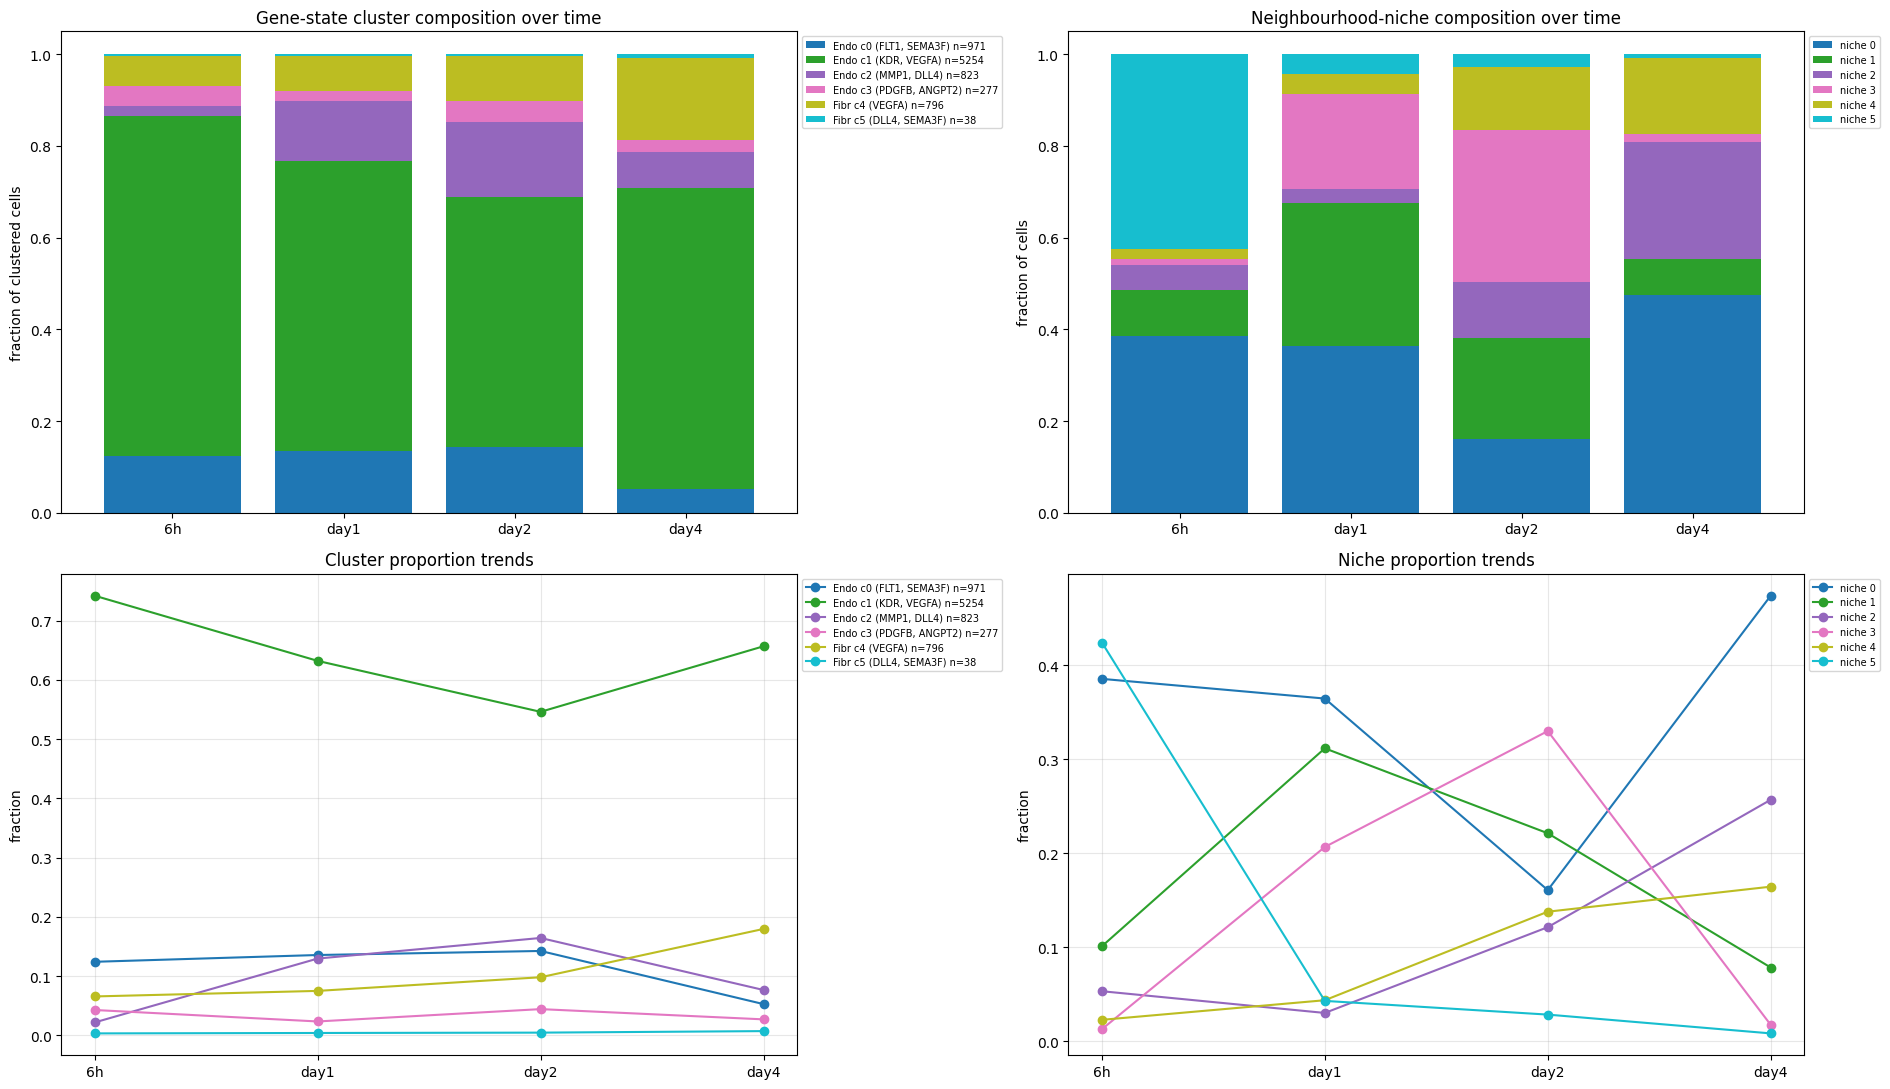

In [44]:
# ==========================================================================
# HOW DO GENE-STATE CLUSTER / NICHE PROPORTIONS CHANGE OVER TIME?
# Timepoint is encoded in the image name (source_folder): 6h -> day1 -> day2 -> day4.
# CAVEAT: each timepoint is a different sample/device (biological-replicate confound), so
# read these as descriptive trends, not statistically powered change.
# ==========================================================================
all_data["timepoint"] = pd.Categorical(all_data[IMAGE_KEY].map(timepoint_of),
                                        categories=TIME_ORDER + ["unknown"], ordered=True)

print("Image -> timepoint mapping:")
for img, tp in sorted(all_data.groupby(IMAGE_KEY)["timepoint"].first().items(), key=lambda kv: str(kv[1])):
    print(f"  {str(tp):6} <- {img}")
print("\nCells per timepoint:")
print(all_data["timepoint"].value_counts().reindex(TIME_ORDER), "\n")

tp_valid = [t for t in TIME_ORDER if (all_data["timepoint"] == t).any()]

# Proportions per timepoint (each column sums to 1 within a timepoint).
clus = all_data[all_data["bmm"] >= 0].copy()
clus["cluster"] = clus["bmm"].map(cluster_name_of)
clus_prop = pd.crosstab(clus["timepoint"], clus["cluster"], normalize="index").reindex(tp_valid)
clus_prop = clus_prop[[c for c in cluster_names if c in clus_prop.columns]]
niche_prop = pd.crosstab(all_data["timepoint"], all_data["niche"], normalize="index").reindex(tp_valid)

print("Gene-state cluster proportion by timepoint:\n", clus_prop.round(3), "\n")
print("Niche proportion by timepoint:\n", niche_prop.round(3))

fig, ax = plt.subplots(2, 2, figsize=(19, 11))
# Row 0: stacked-bar composition. Row 1: per-group line trends.
clus_colors = [cluster_palette[c] for c in clus_prop.columns]
niche_colors = [niche_color[n] for n in niche_prop.columns]

clus_prop.plot(kind="bar", stacked=True, ax=ax[0, 0], color=clus_colors, width=0.8)
ax[0, 0].set(title="Gene-state cluster composition over time", ylabel="fraction of clustered cells", xlabel="")
ax[0, 0].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax[0, 0].tick_params(axis="x", rotation=0)

niche_prop.plot(kind="bar", stacked=True, ax=ax[0, 1], color=niche_colors, width=0.8)
ax[0, 1].set(title="Neighbourhood-niche composition over time", ylabel="fraction of cells", xlabel="")
ax[0, 1].legend([f"niche {n}" for n in niche_prop.columns], fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
ax[0, 1].tick_params(axis="x", rotation=0)

for c, col in zip(clus_prop.columns, clus_colors):
    ax[1, 0].plot(range(len(tp_valid)), clus_prop[c].values, "o-", color=col, label=c)
ax[1, 0].set(title="Cluster proportion trends", ylabel="fraction", xticks=range(len(tp_valid)))
ax[1, 0].set_xticklabels(tp_valid); ax[1, 0].grid(alpha=0.3)
ax[1, 0].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")

for n, col in zip(niche_prop.columns, niche_colors):
    ax[1, 1].plot(range(len(tp_valid)), niche_prop[n].values, "o-", color=col, label=f"niche {n}")
ax[1, 1].set(title="Niche proportion trends", ylabel="fraction", xticks=range(len(tp_valid)))
ax[1, 1].set_xticklabels(tp_valid); ax[1, 1].grid(alpha=0.3)
ax[1, 1].legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")

plt.tight_layout(); plt.show()


### Conclusions - gene modules

**Approach.** A gene-gene graph from significant **positive** co-occurrences in endothelial
cells. Edge weight = **log2 odds ratio** (effect size). The **pan-endothelial markers** (`CDH5`,
`VWF`, `PECAM1`) and **collagen** (`COL1A1`, `COL1A2`) are **excluded** - they define the lineage /
stroma and carry no module information. Communities on the remaining functional genes = co-firing
**modules** (greedy modularity, resolution 1.5); module activity is then averaged per niche.

**How real are the modules? (quantified, not eyeballed).** Weighting edges by the **log2 odds
ratio** and taking the **resolution-1.5** greedy partition gives **5 modules (Q = 0.21)**. The two
angiogenic modules (VEGF-core, tip/sprouting) are metric- and resolution-stable; using log2 OR
(rather than phi) additionally splits the perivascular genes into a **mural** (`PDGFB`/`PDGFRB`)
and a **remodelling** (`ANGPT2`/`APLN`) module - phi keeps them merged as one - a split that is
independently favoured by the spatial niches (see below).

**Assumptions / drawbacks.** Co-occurrence is association, not causal regulation. Only positive
edges are used; the number of modules depends on the edge weight and resolution (phi -> 4, log2 OR
-> 5); and this is built on endothelial cells only (the dominant lineage).

**Biology - five co-firing modules:**
- **VEGF / angiogenic core** - `KDR`, `VEGFA`, `ITGA6`: the VEGF-activation programme.
- **Tip / sprouting** - `DLL4`, `MMP1`, `SEMA3F`, `FLT1`: Notch tip-selection + ECM-remodelling
  / guidance genes.
- **Mural / pericyte** - `PDGFB`, `PDGFRB`: pericyte recruitment (`PDGFB` ligand + `PDGFRB` receptor).
- **Remodelling / apelin** - `ANGPT2`, `APLN`: vessel destabilisation + apelin-tip remodelling.
- **Activated / inflammatory-Notch** - `ICAM1`, `JAG1`: endothelial activation / stalk-Notch.

**Do the methods agree?** The two angiogenic modules map cleanly onto the tissue: **VEGF-core and
tip/sprouting both light up the angiogenic niches** (the `MMP1`/`VEGFA` and `FLT1`/`DLL4` niches)
and match the `KDR`/`VEGFA` and `FLT1`/`DLL4` gene-state clusters. The smaller modules map to
distinct micro-environments too: **mural** (`PDGFB`/`PDGFRB`) -> the `PDGFRB` mural niche, and
**remodelling** (`ANGPT2`/`APLN`) -> the `APLN`/`ANGPT2` niche - so splitting the perivascular block
into mural vs remodelling is corroborated spatially. Only the **`ICAM1`/`JAG1`** pair stays a
gene-level association whose two genes sit in different niches, i.e. not spatially co-located.

---

## Overall biological conclusion

The sample is a **majority-endothelial vascular bed** (~7.4k endothelial vs ~0.7k
fibroblast cells with reads) with a minor, discrete fibroblast population. Endothelial cells
are **not discrete cell types but a continuum** on a shared `CDH5` (VE-cadherin) backbone,
structured by a small number of overlapping programmes.

### Marker glossary (what the genes mean here)

| Gene | Role | Programme it marks |
|---|---|---|
| `CDH5` (VE-cadherin) | pan-endothelial junctional identity | backbone (all endothelium) |
| `KDR` (VEGFR2) | main pro-angiogenic VEGF receptor | **VEGF / angiogenic core** |
| `VEGFA` | pro-angiogenic ligand (auto/paracrine) | **VEGF / angiogenic core** |
| `ITGA6` | laminin integrin, migration / basement membrane | VEGF / angiogenic core |
| `DLL4` | Notch ligand, **tip-cell selection** | **tip / sprouting** |
| `FLT1` (VEGFR1) | VEGF decoy receptor, tip/stalk balance | **tip / sprouting** |
| `MMP1` | matrix metalloprotease, ECM breakdown for sprouting | **tip / sprouting** |
| `SEMA3F` | semaphorin guidance cue | tip / sprouting |
| `ICAM1` | endothelial activation / adhesion | activated / Notch |
| `APLN` (apelin) | classic **tip-cell** marker | remodelling / apelin |
| `PDGFB` | pericyte-recruitment signal from tip cells | mural / pericyte |
| `ANGPT2` | Tie2 ligand, vessel destabilisation / remodelling | remodelling / apelin |
| `VWF`, `PECAM1` | mature/large-vessel endothelial markers | mature vessel |
| `JAG1` | Notch ligand (stalk / mural) | activated / Notch |
| `PDGFRB`, `COL1A1/2` | mural / fibroblast markers | non-angiogenic stroma |

### The endothelial gene-state clusters (Section 2, markers `CDH5`/`VWF`/`PECAM1` excluded from the clustering)

| State | n (%) | Defining markers (upregulated) | Spatial cohesion z | What it is | Angiogenic? |
|---|---|---|---|---|---|
| **c3 - quiescent backbone** | 4,589 (62%) | `CDH5` only, low `KDR` | +4.5 (mostly diffuse) | resting / phalanx endothelium | **no** |
| **c0 - VEGF-activated** | 1,383 (19%) | `KDR` + `VEGFA` | +6.6 | canonical angiogenic activation | **YES (core)** |
| **c2 - tip / sprouting** | 1,092 (15%) | `FLT1` + `DLL4` (+`VEGFA`) | **+9.3 (strongest patches)** | sprouting tip / stalk front | **YES (tip)** |
| **c1 - apelin / PDGFB sprout** | 324 (4%) | `APLN` + `PDGFB` (+`VEGFA`/`DLL4`) | +5.9 | apelin+ tip-like, pericyte-recruiting | **YES (tip-associated)** |

So the **angiogenic states are c0, c2 and c1**:
- **c0** is the *core VEGF-driven angiogenic* state - `KDR`(VEGFR2) receiving `VEGFA` on the
  `CDH5` backbone. This is the main axis of the whole endothelial continuum (it is also
  logistic-PCA axis 1: `KDR`+`VEGFA` vs the plain `CDH5` core).
- **c2** is the *tip / sprouting* state - `DLL4`+`FLT1`(+`MMP1`), i.e. Notch-driven tip
  selection plus ECM-remodelling for sprout invasion. It forms the **tightest spatial
  patches (z = +9.3)**, consistent with sprouting fronts being physically clustered.
- **c1** is a smaller *apelin/PDGFB* sprouting-associated state (`APLN` is a textbook
  tip-cell marker; `PDGFB` recruits pericytes) - a tip-to-mural transition flavour.
- **c3** (the 62% majority) is **not** angiogenic - it is `CDH5`-only quiescent endothelium,
  and it is spatially **diffuse** (z only +4.5), i.e. a shared baseline rather than a
  discrete patchy state.

### The same angiogenic signal in the other two views

- **Gene modules (Section 4).** With markers and collagen dropped and edges weighted by log2 OR,
  the co-occurrence graph resolves into **five modules (Q~0.21)** at resolution 1.5: a **VEGF /
  angiogenic core** (`KDR`, `VEGFA`, `ITGA6`), a **tip / sprouting** module (`DLL4`, `MMP1`,
  `SEMA3F`, `FLT1` - the genes defining states c0 and c2), a **mural / pericyte** module
  (`PDGFB`, `PDGFRB`), a **remodelling / apelin** module (`ANGPT2`, `APLN`), and a small
  **activated / inflammatory-Notch** module (`ICAM1`, `JAG1`). The two angiogenic modules and the
  mural vs remodelling split all *corroborate* the state/niche programmes; only `ICAM1`/`JAG1` is soft.
- **Spatial niches (Section 3).** The angiogenic niches are **niche 1** (`MMP1`/`VEGFA`/
  `DLL4` - a proteolytic-angiogenic front), **niche 3** (`FLT1`/`ITGA6`/`DLL4` - the
  tip/sprouting niche), and **niche 5** (`ICAM1`/`SEMA3F`/`PDGFB` - activated/guidance),
  with **niche 4** (`APLN`/`ANGPT2`) a remodelling flavour. Niche 2 (`PDGFRB`/`COL1A1`/
  `JAG1`) is mural/fibroblast and niche 0 is low-signal quiescent - the non-angiogenic
  environments.

**Bottom line.** The `KDR`/`VEGFA` **angiogenic activation** axis (state c0) and the
`DLL4`/`FLT1`/`MMP1` **tip/sprouting** axis (state c2) are the two angiogenic programmes, and
they recur as gene-state clusters, gene modules, and spatial niches - and form real spatial
patches. The bulk `CDH5`-only endothelium is quiescent and diffuse, and fibroblasts
(`PDGFRB`/collagen) are few, discrete, and spatially segregated from the angiogenic
endothelium.

**Caveats to keep in mind:** the gene-module partition is only **modestly modular** (Q~0.21,
and the module count is weight/resolution-dependent: phi gives 4, log2 OR splits the perivascular
block into mural + remodelling for 5) - the two angiogenic modules are robust and the mural vs
remodelling split is spatially supported, but the `ICAM1`/`JAG1` boundary should not be over-read;
all-0-read cells were assigned lineages artificially and carry no state; co-occurrence and spatial
adjacency are associations, not proof of interaction or regulation; very small clusters (e.g. c1
n=324, or the n~12 fibroblast state) and the chosen k / niche-count are not robust; marker
identities above are the conventional vascular-biology readings of these genes, not validated here;
and this is a single replicate.


In [45]:
# ==========================================================================
# SAVE part-4 outputs (niches + gene modules) for the part-5 write-up.
# ==========================================================================
niche_gene_z.to_csv(output_dir / "part4_niche_fingerprint.csv")             # niche x gene (z-scored nbhd expr)
state_comp.to_csv(output_dir / "part4_niche_state_composition.csv")         # niche x gene-state fraction
niche_module.to_csv(output_dir / "part4_module_activity_per_niche.csv")     # niche x module activity
pd.DataFrame({"gene": MODULE_GENES,
              "module": [module_of[g] for g in MODULE_GENES],
              "on_freq": on_freq}).to_csv(output_dir / "part4_gene_modules.csv", index=False)
pos[["g1", "g2", "log2_OR"]].to_csv(output_dir / "part4_module_edges.csv", index=False)
print("Saved -> part4_niche_fingerprint.csv, part4_niche_state_composition.csv, "
      "part4_module_activity_per_niche.csv, part4_gene_modules.csv, part4_module_edges.csv")


Saved -> part4_niche_fingerprint.csv, part4_niche_state_composition.csv, part4_module_activity_per_niche.csv, part4_gene_modules.csv, part4_module_edges.csv


Spatial autocorrelation (Moran's I) of module activity in dev7_3_day1_large:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.067  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.126  p = 0.005  -> patchy
  mod 2: ICAM1, JAG1                 I = +0.039  p = 0.005  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.037  p = 0.005  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.011  p = 0.060  -> intermixed


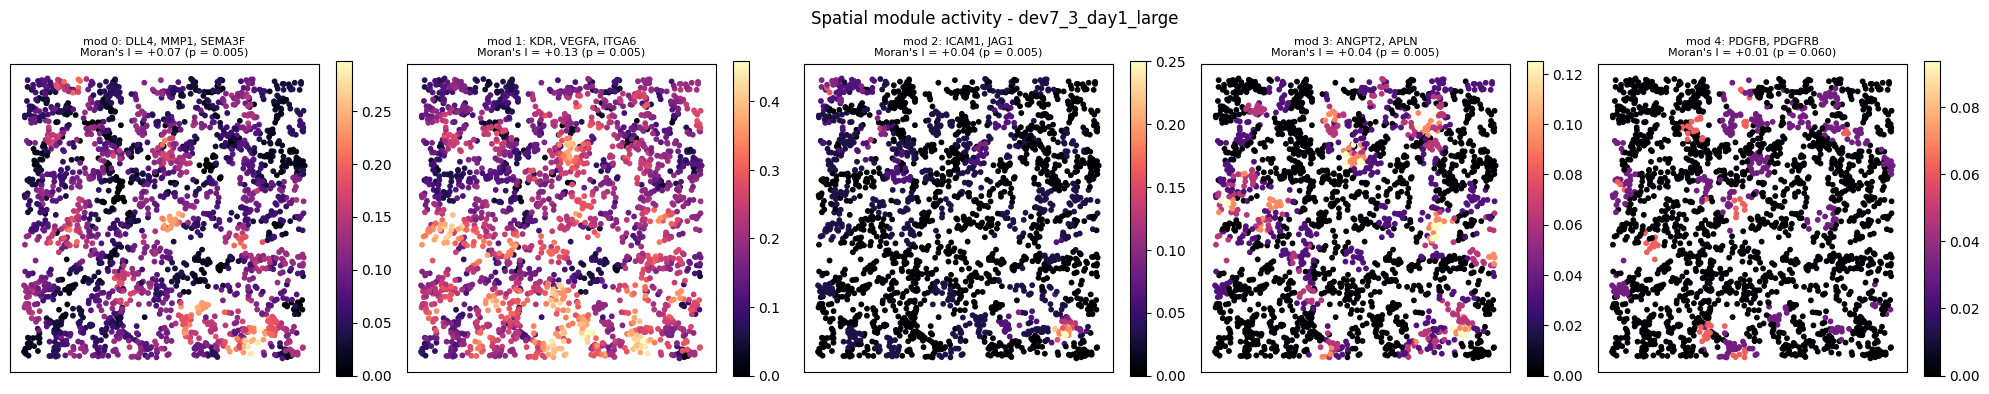

Spatial autocorrelation (Moran's I) of module activity in dev4_1_6h:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.043  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.087  p = 0.005  -> intermixed
  mod 2: ICAM1, JAG1                 I = +0.018  p = 0.020  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.016  p = 0.050  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.113  p = 0.005  -> patchy


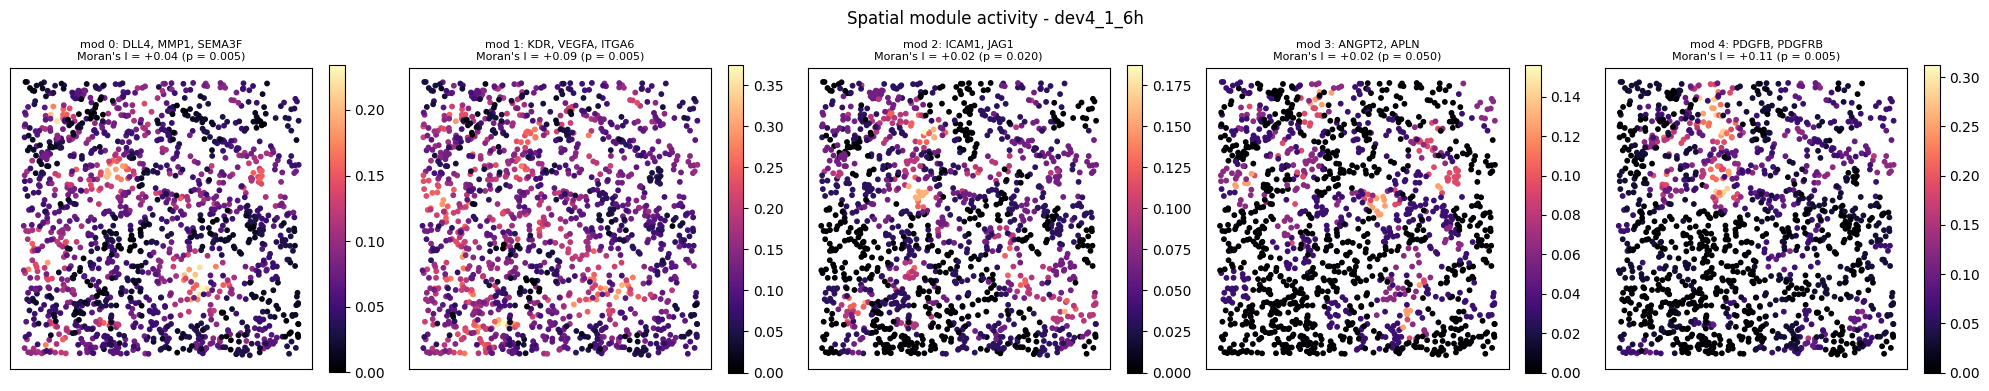

Spatial autocorrelation (Moran's I) of module activity in dev4_2_6h:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.093  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.031  p = 0.005  -> intermixed
  mod 2: ICAM1, JAG1                 I = +0.031  p = 0.010  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.024  p = 0.020  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.065  p = 0.005  -> intermixed


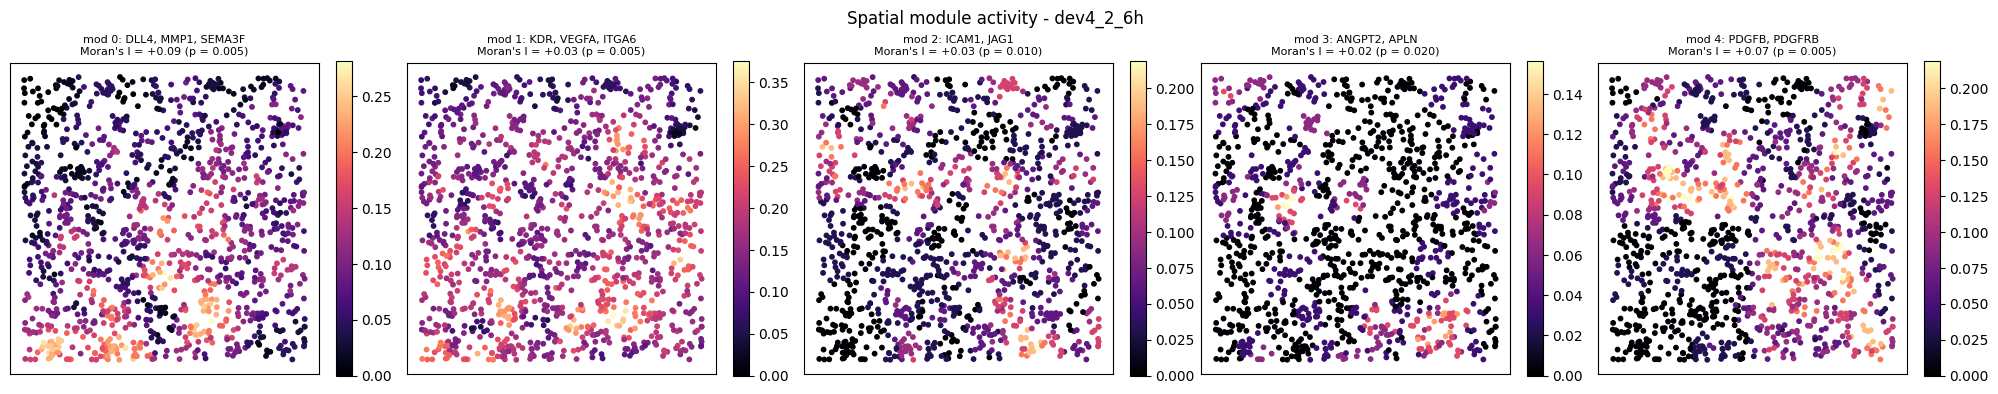

Spatial autocorrelation (Moran's I) of module activity in dev10_3_day2:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.058  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.093  p = 0.005  -> intermixed
  mod 2: ICAM1, JAG1                 I = +0.017  p = 0.040  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.031  p = 0.010  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.091  p = 0.005  -> intermixed


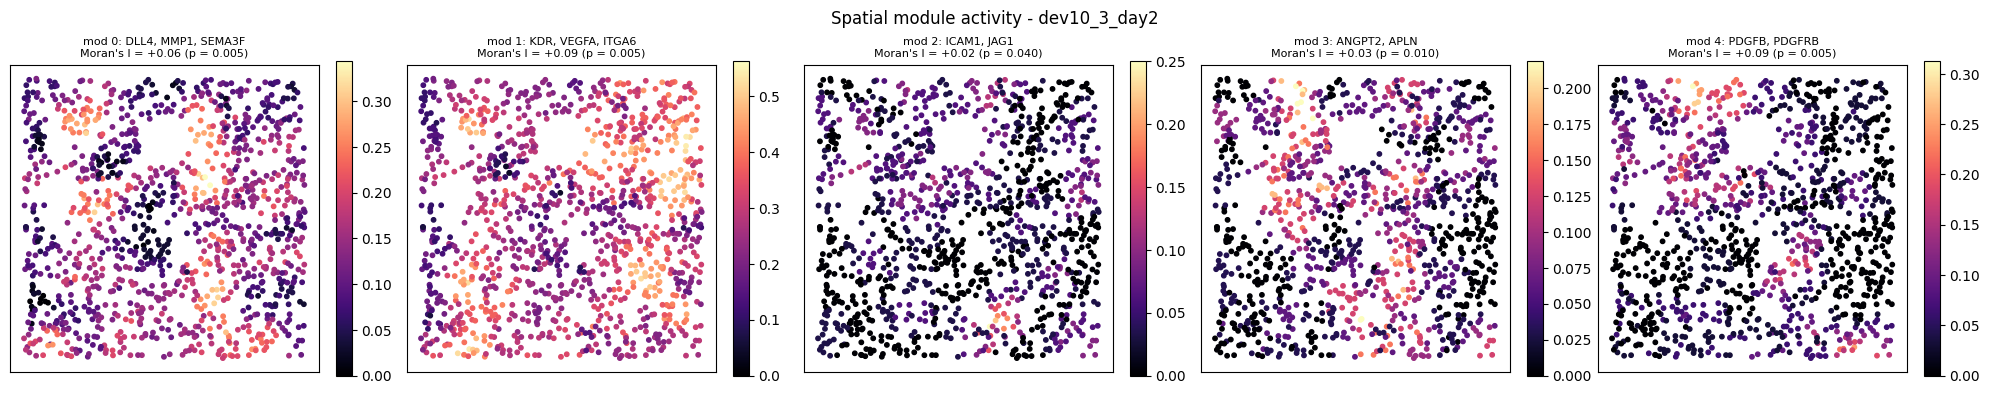

Spatial autocorrelation (Moran's I) of module activity in dev7_3_day1:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.036  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.116  p = 0.005  -> patchy
  mod 2: ICAM1, JAG1                 I = +0.006  p = 0.294  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.010  p = 0.164  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.042  p = 0.005  -> intermixed


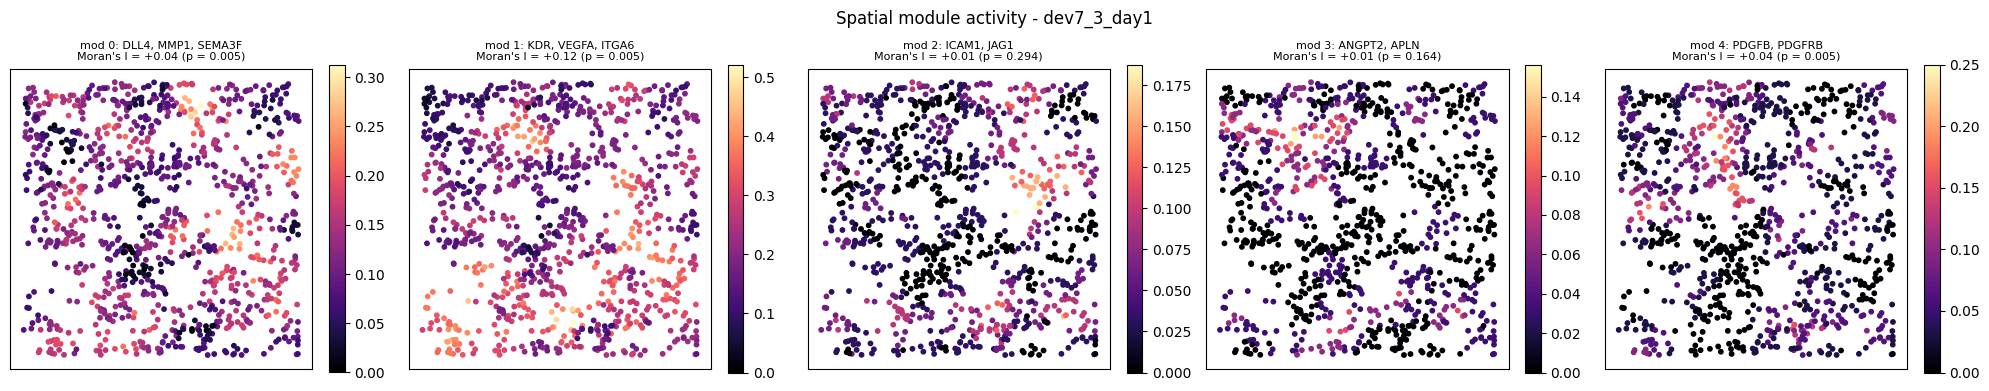

Spatial autocorrelation (Moran's I) of module activity in dev10_4_day2:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.061  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.042  p = 0.010  -> intermixed
  mod 2: ICAM1, JAG1                 I = +0.014  p = 0.114  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.035  p = 0.005  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.074  p = 0.005  -> intermixed


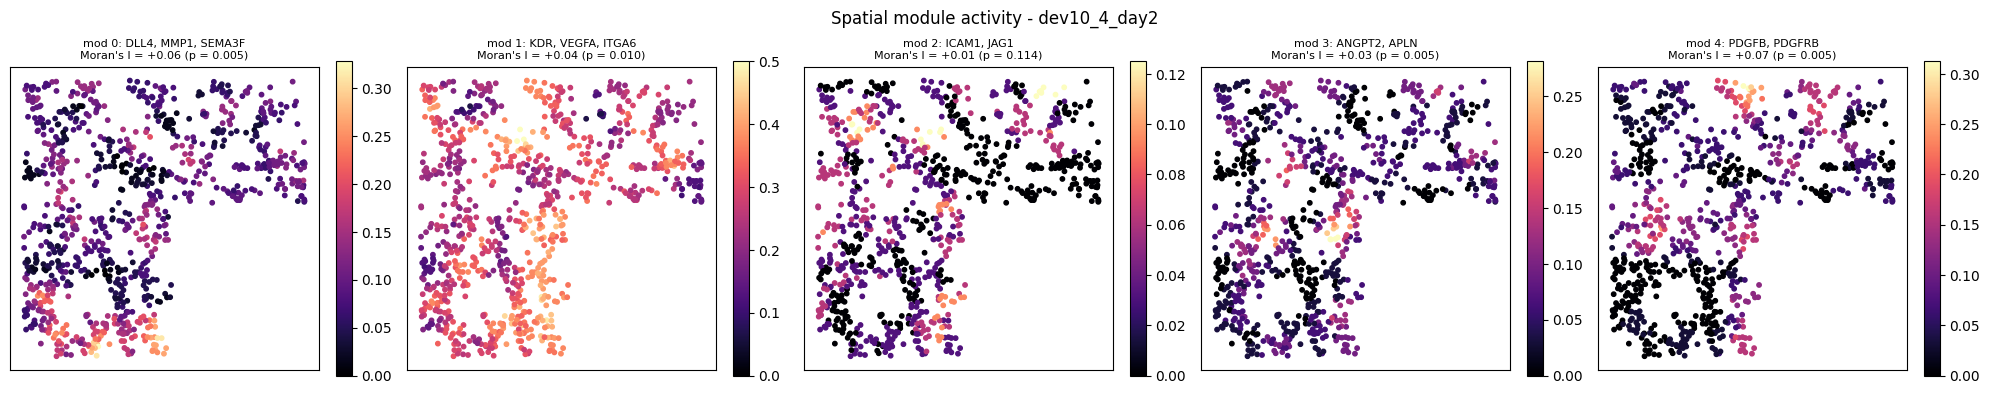

Spatial autocorrelation (Moran's I) of module activity in dev10_2_day4:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.015  p = 0.085  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.051  p = 0.005  -> intermixed
  mod 2: ICAM1, JAG1                 I = +0.044  p = 0.005  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.052  p = 0.005  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.032  p = 0.005  -> intermixed


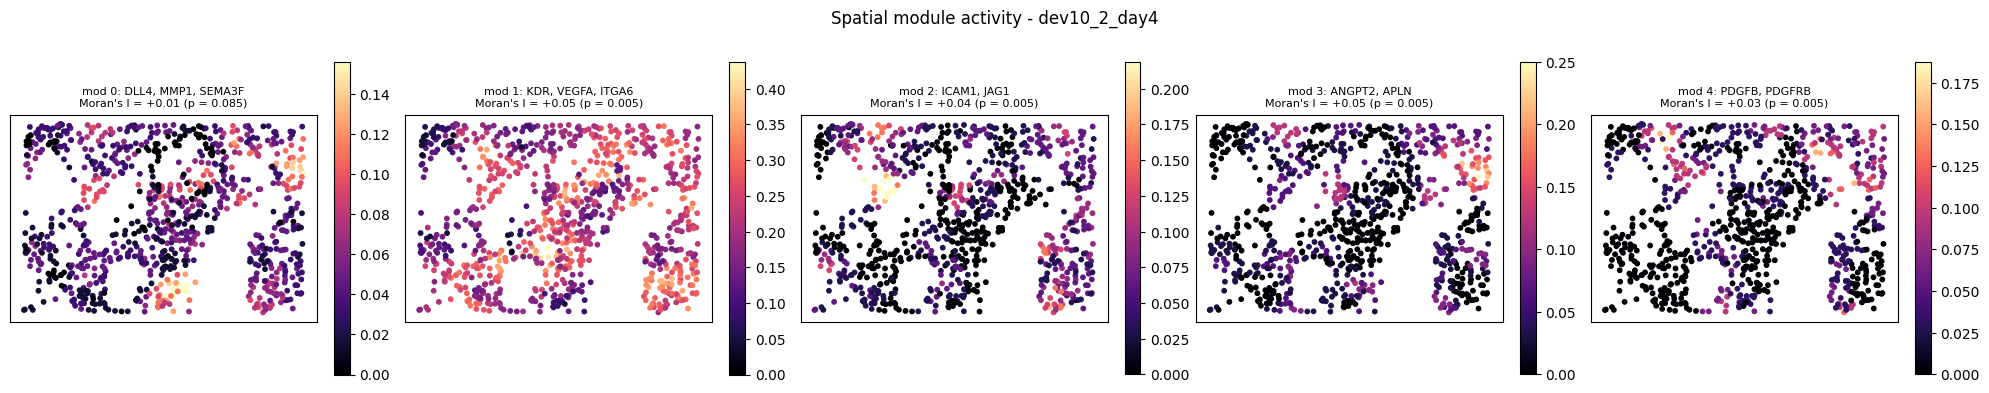

Spatial autocorrelation (Moran's I) of module activity in dev7_2_day1:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.042  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.025  p = 0.025  -> intermixed
  mod 2: ICAM1, JAG1                 I = -0.019  p = 0.965  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.024  p = 0.030  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.029  p = 0.005  -> intermixed


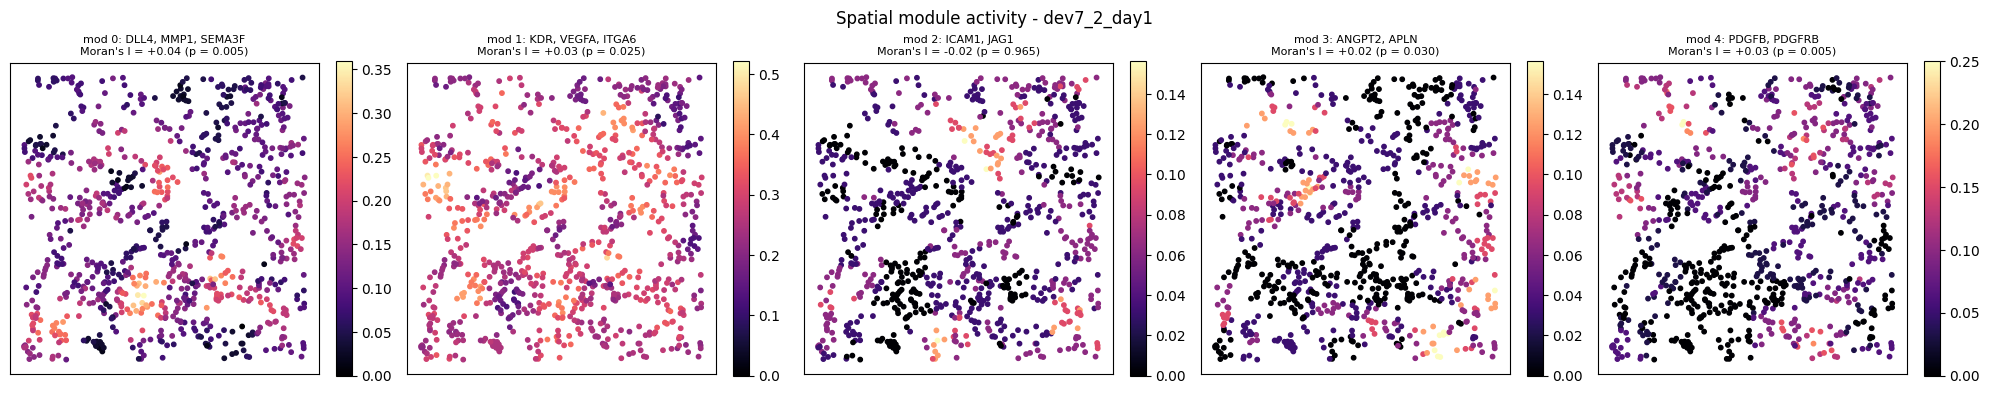

Spatial autocorrelation (Moran's I) of module activity in dev10_4_day4:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.017  p = 0.080  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.033  p = 0.005  -> intermixed
  mod 2: ICAM1, JAG1                 I = -0.002  p = 0.423  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.076  p = 0.005  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.065  p = 0.005  -> intermixed


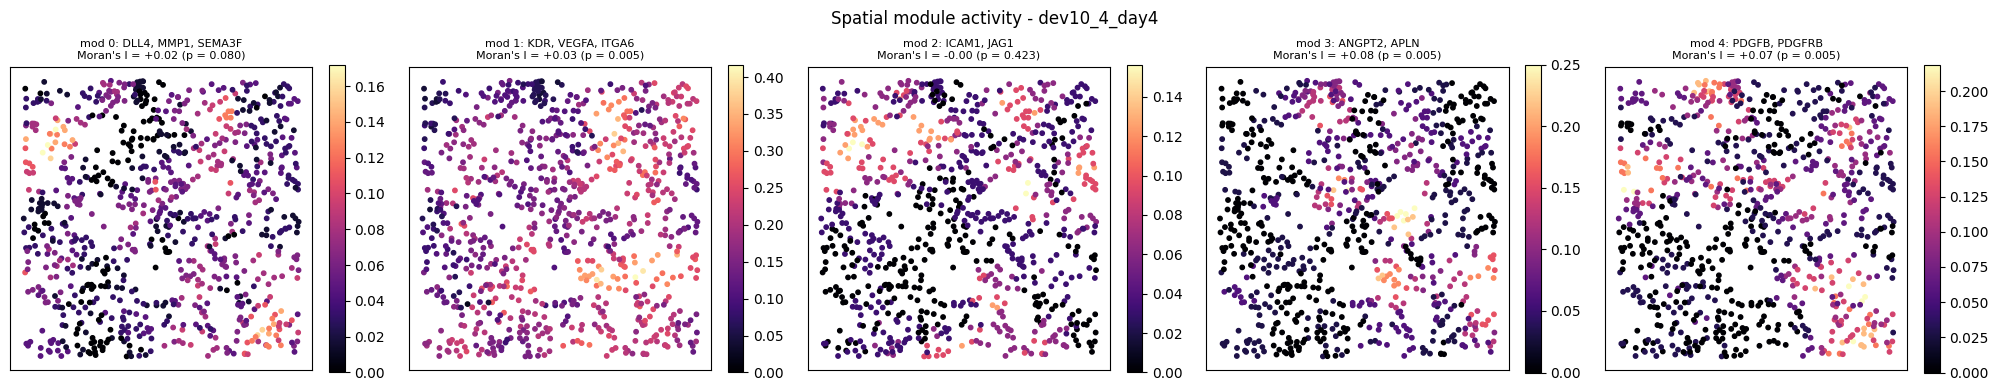

Spatial autocorrelation (Moran's I) of module activity in dev9_4_day4:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.078  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.107  p = 0.005  -> patchy
  mod 2: ICAM1, JAG1                 I = +0.039  p = 0.005  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.057  p = 0.005  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.031  p = 0.020  -> intermixed


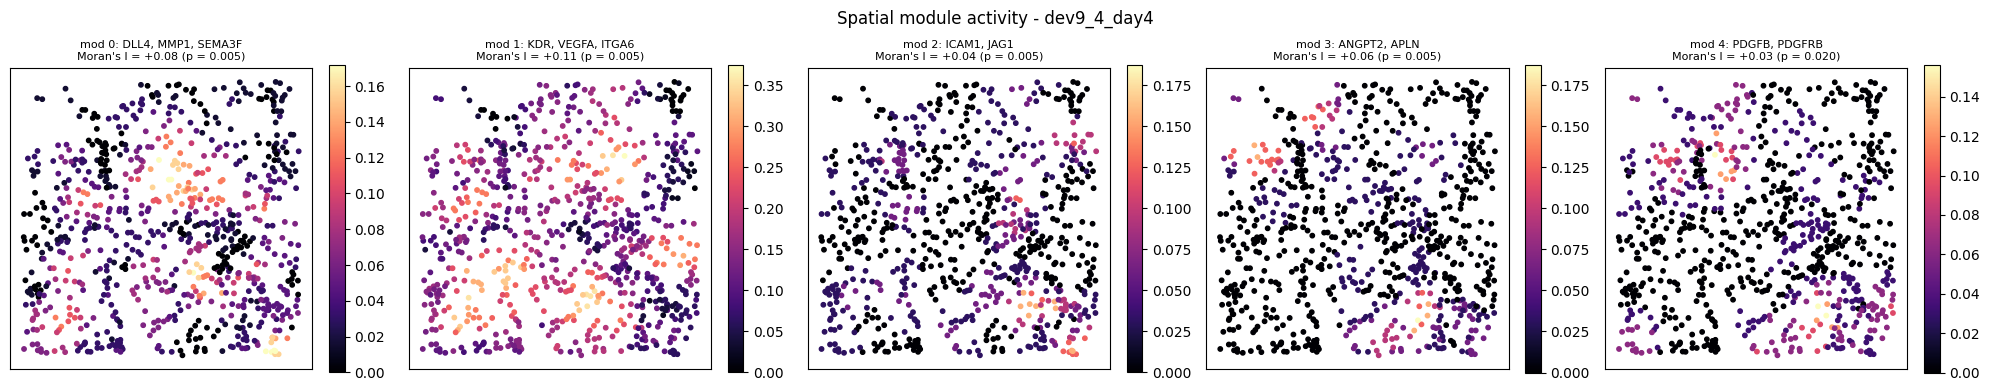

Spatial autocorrelation (Moran's I) of module activity in dev4_3_6h:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.020  p = 0.030  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.025  p = 0.015  -> intermixed
  mod 2: ICAM1, JAG1                 I = +0.009  p = 0.164  -> intermixed
  mod 3: ANGPT2, APLN                I = -0.000  p = 0.438  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.043  p = 0.010  -> intermixed


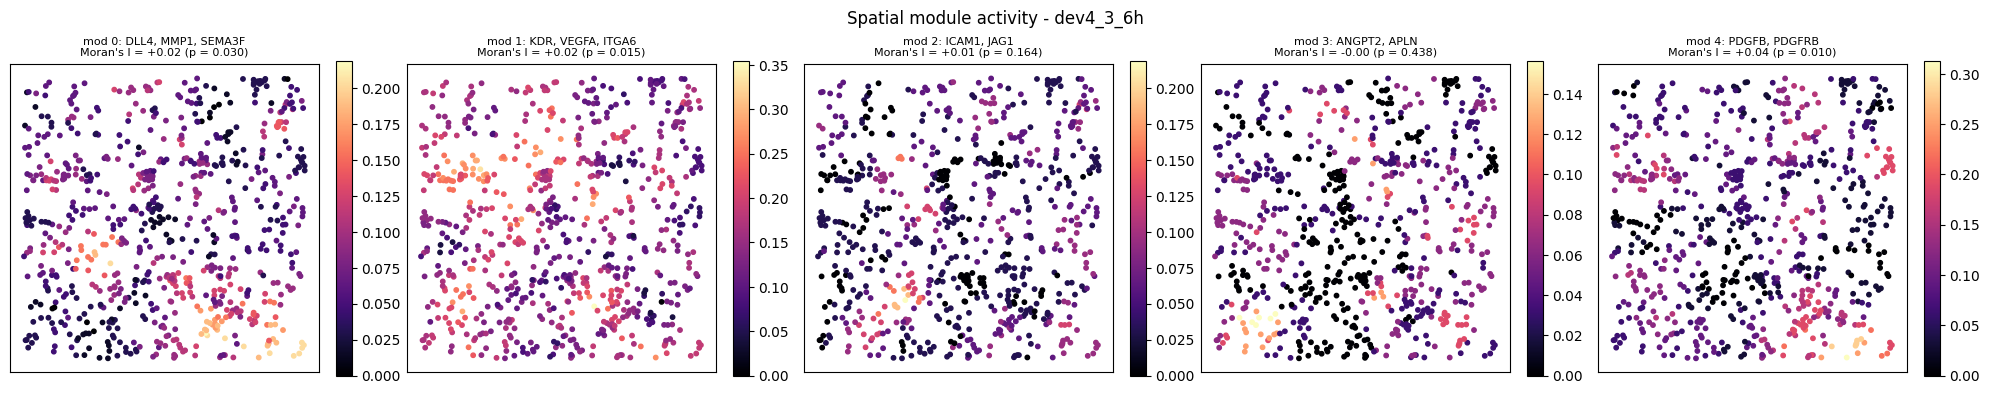

Spatial autocorrelation (Moran's I) of module activity in dev10_1_day2:
  mod 0: DLL4, MMP1, SEMA3F          I = +0.045  p = 0.005  -> intermixed
  mod 1: KDR, VEGFA, ITGA6           I = +0.062  p = 0.005  -> intermixed
  mod 2: ICAM1, JAG1                 I = -0.001  p = 0.378  -> intermixed
  mod 3: ANGPT2, APLN                I = +0.049  p = 0.010  -> intermixed
  mod 4: PDGFB, PDGFRB               I = +0.040  p = 0.025  -> intermixed


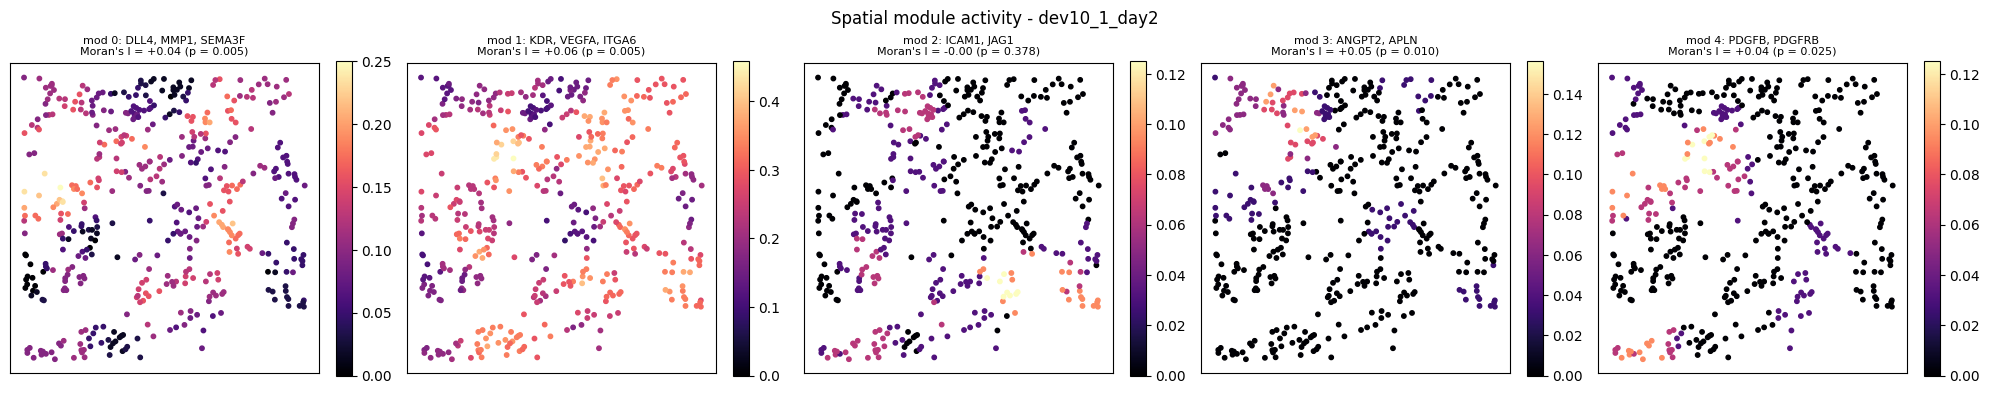

In [71]:
# ===== SPATIAL MAPS + SPATIAL AUTOCORRELATION OF THE 5 GENE MODULES =====
# Per-cell module activity = fraction of that module's genes ON. Mapped in space (KNN-smoothed
# to reveal gradients) and scored with Moran's I to say which modules are patchy vs intermixed.
module_cols = [module_labels[m] for m in range(len(communities))]
mod_act = pd.DataFrame({module_labels[m]: all_data[list(com)].mean(axis=1)
                        for m, com in enumerate(communities)}, index=all_data.index)

# KNN-smoothed activity (mean over the K nearest neighbours + self, within each image).
A = mod_act.to_numpy()
smoothed = np.zeros_like(A)
neighbour_index_by_image = {}
for image_name, sub in all_data.groupby(IMAGE_KEY):
    pos = sub.index.to_numpy()
    coords = sub[["x_um", "y_um", "z_um"]].to_numpy()
    _, idx = cKDTree(coords).query(coords, k=min(K_SPATIAL + 1, len(sub)))
    idx = np.atleast_2d(idx)
    smoothed[pos] = A[pos[idx]].mean(axis=1)
    neighbour_index_by_image[image_name] = (pos, idx[:, 1:] if idx.shape[1] > 1 else idx)  # drop self
mod_smooth = pd.DataFrame(smoothed, columns=module_cols, index=all_data.index)

def morans_i(values, neighbours, n_perm=200, seed=0):
    """Moran's I of `values` on a fixed neighbour graph (row-uniform weights) + permutation p."""
    z = values - values.mean()
    W = neighbours.size
    n = len(values)
    stat = (n / W) * np.sum(z[:, None] * z[neighbours]) / np.sum(z ** 2)
    rng = np.random.default_rng(seed)
    null = np.array([(n / W) * np.sum((zp := rng.permutation(z))[:, None] * zp[neighbours]) / np.sum(zp ** 2)
                     for _ in range(n_perm)])
    return stat, (np.sum(null >= stat) + 1) / (n_perm + 1)

# # Moran's I per module, computed within the largest image (single coordinate frame).
# image_name = all_data[IMAGE_KEY].value_counts().index[0]



for image_name in all_data[IMAGE_KEY].value_counts().index[:]:  # largest 2 images
    pos, nb = neighbour_index_by_image[image_name]
    print(f"Spatial autocorrelation (Moran's I) of module activity in {image_name}:")
    moran_by_col = {}
    for col in module_cols:
        I, p = morans_i(mod_act.loc[pos, col].to_numpy(), nb)
        moran_by_col[col] = (I, p)
        verdict = "patchy" if (I > 0.1 and p < 0.05) else "intermixed"
        print(f"  {col:34s} I = {I:+.3f}  p = {p:.3f}  -> {verdict}")
    # Spatial maps (KNN-smoothed) of each module on that image.
    sub = all_data.loc[pos]
    fig, axes = plt.subplots(1, len(module_cols), figsize=(4 * len(module_cols), 4), squeeze=False)
    for ax, col in zip(axes[0], module_cols):
        I, p = moran_by_col[col]
        s = ax.scatter(sub["x_um"], sub["y_um"], c=mod_smooth.loc[pos, col], s=10, cmap="magma", vmin=0)
        ax.set_title(f"{col}\nMoran's I = {I:+.2f} (p = {p:.3f})", fontsize=8)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(s, ax=ax, fraction=0.046)
    fig.suptitle(f"Spatial module activity - {image_name}")
    plt.tight_layout(); 
    plt.savefig(r"z:\Bel\Jorge_SPACEFISH_Examples\Patchyness_Outputs" + f"\{image_name}.png")
    plt.show()

Mean Moran's I per module by timepoint (higher = patchy, ~0 = intermixed):
           mod 0: DLL4, MMP1, SEMA3F  mod 1: KDR, VEGFA, ITGA6  \
timepoint                                                        
6h                             0.052                     0.048   
day1                           0.048                     0.089   
day2                           0.055                     0.065   
day4                           0.037                     0.064   

           mod 2: ICAM1, JAG1  mod 3: ANGPT2, APLN  mod 4: PDGFB, PDGFRB  
timepoint                                                                 
6h                      0.019                0.013                 0.074  
day1                    0.009                0.024                 0.028  
day2                    0.010                0.038                 0.068  
day4                    0.027                0.062                 0.043   

Images averaged per timepoint: {'6h': 3, 'day1': 3, 'day2': 3, 'day4': 3}


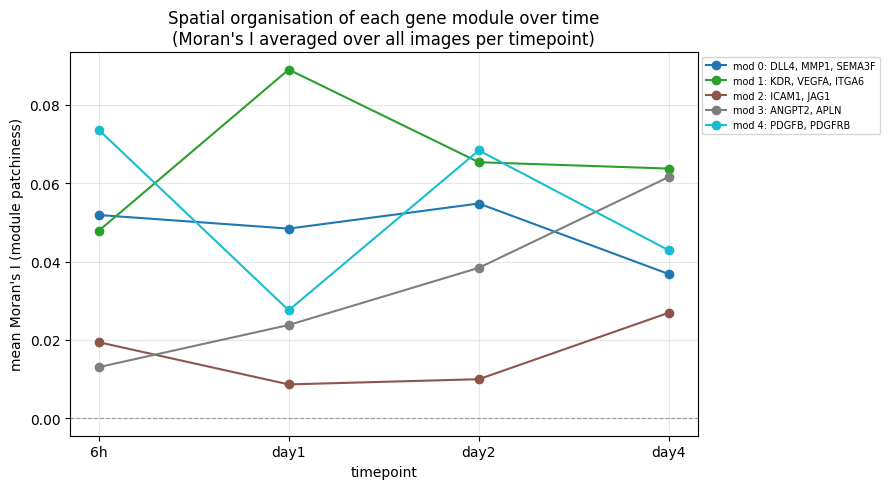

In [59]:
# ===== MODULE PATCHINESS OVER TIME (Moran's I averaged across images per timepoint) =====
# For each image, Moran's I of every module's activity on its KNN graph; averaged over all
# images in a timepoint -> does each programme get more spatially organised (patchy, I up) or
# stay intermixed (I ~ 0) as angiogenesis proceeds? Images with < MIN_CELLS cells are skipped.
MIN_CELLS = 20

def morans_i_stat(values, neighbours):
    """Moran's I only (no permutation); NaN if the values carry no variance."""
    z = values - values.mean()
    ss = np.sum(z ** 2)
    if ss == 0 or neighbours.size == 0:
        return np.nan
    return (len(values) / neighbours.size) * np.sum(z[:, None] * z[neighbours]) / ss

moran_records = {
    image_name: {col: morans_i_stat(mod_act.loc[pos, col].to_numpy(), nb) for col in module_cols}
    for image_name, (pos, nb) in neighbour_index_by_image.items() if len(pos) >= MIN_CELLS}

moran_by_image = pd.DataFrame(moran_records).T                              # images x modules
moran_by_image["timepoint"] = [timepoint_of(img) for img in moran_by_image.index]
tp_present = [t for t in TIME_ORDER if t in set(moran_by_image["timepoint"])]
moran_by_time = moran_by_image.groupby("timepoint")[module_cols].mean().reindex(tp_present)
images_per_tp = moran_by_image.groupby("timepoint").size().reindex(tp_present)

print("Mean Moran's I per module by timepoint (higher = patchy, ~0 = intermixed):")
print(moran_by_time.round(3), "\n")
print("Images averaged per timepoint:", images_per_tp.to_dict())

module_cmap = plt.get_cmap("tab10", len(module_cols))
fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(module_cols):
    ax.plot(range(len(tp_present)), moran_by_time[col].values, "o-", color=module_cmap(i), label=col)
ax.axhline(0, color="0.6", lw=0.8, ls="--")
ax.set(xlabel="timepoint", ylabel="mean Moran's I (module patchiness)",
       title="Spatial organisation of each gene module over time\n(Moran's I averaged over all images per timepoint)",
       xticks=range(len(tp_present)))
ax.set_xticklabels(tp_present); ax.grid(alpha=0.3)
ax.legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.tight_layout(); plt.show()


Mean module activity (fraction of module genes ON) by timepoint:
           mod 0: DLL4, MMP1, SEMA3F  mod 1: KDR, VEGFA, ITGA6  \
timepoint                                                        
6h                             0.110                     0.201   
day1                           0.147                     0.317   
day2                           0.142                     0.359   
day4                           0.076                     0.290   

           mod 2: ICAM1, JAG1  mod 3: ANGPT2, APLN  mod 4: PDGFB, PDGFRB  
timepoint                                                                 
6h                      0.055                0.035                 0.101  
day1                    0.034                0.031                 0.045  
day2                    0.034                0.055                 0.052  
day4                    0.031                0.054                 0.040  


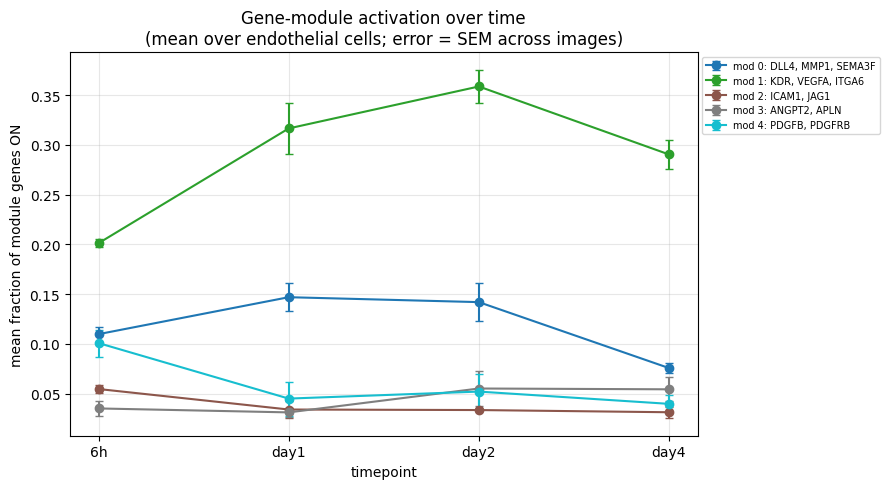

In [60]:
# ===== MODULE ACTIVATION OVER TIME (mean fraction of module genes ON) =====
# How strongly each module fires on average, per timepoint (complements the patchiness trend).
# Averaged per image first (mean of image means +/- SEM across images) so large images don't
# dominate. Endothelial cells with reads only - the lineage the modules describe.
endo_mod = mod_act.loc[(all_data["cell_type"] == "Endothelial") & all_data["has_reads"]].copy()
endo_mod["image"] = all_data.loc[endo_mod.index, IMAGE_KEY]
endo_mod["timepoint"] = [timepoint_of(img) for img in endo_mod["image"]]

image_means = endo_mod.groupby(["timepoint", "image"])[module_cols].mean()
tp_present = [t for t in TIME_ORDER if t in image_means.index.get_level_values("timepoint")]
activation_mean = image_means.groupby(level="timepoint")[module_cols].mean().reindex(tp_present)
activation_sem = image_means.groupby(level="timepoint")[module_cols].sem().reindex(tp_present)

print("Mean module activity (fraction of module genes ON) by timepoint:")
print(activation_mean.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(module_cols):
    ax.errorbar(range(len(tp_present)), activation_mean[col].values, yerr=activation_sem[col].values,
                fmt="o-", capsize=3, color=module_cmap(i), label=col)
ax.set(xlabel="timepoint", ylabel="mean fraction of module genes ON",
       title="Gene-module activation over time\n(mean over endothelial cells; error = SEM across images)",
       xticks=range(len(tp_present)))
ax.set_xticklabels(tp_present); ax.grid(alpha=0.3)
ax.legend(fontsize=7, bbox_to_anchor=(1.0, 1.0), loc="upper left")
plt.tight_layout(); plt.show()